# Projeto Final - Analise de eventos LHE

## Parte 1: Leitura do LHE como arquivo texto

Este notebook e uma opcao de trabalho para estudantes. Ele nao contem codigo
pronto.

A ideia e usar cada celula de instrucao para pedir a um agente que gere o codigo
correspondente ao metodo **texto**. Depois, copie o codigo produzido pelo
agente para a celula vazia logo abaixo e execute no seu ambiente.

Arquivos da amostra:

- sinal: `../data/sinal.lhe.gz`;
- fundo: `../data/fundo.lhe.gz`.

Mantenha as respostas, tabelas, figuras e interpretacoes no proprio notebook.


## 0. Preparação no Google Colab

Se você baixou este repositório como arquivo `.zip` pelo GitHub e fez o upload no Google Colab, comece pedindo ao agente que gere um pequeno código para descompactar o `.zip` no ambiente do Colab, entrar na pasta extraída e confirmar que os arquivos `data/sinal.lhe.gz` e `data/fundo.lhe.gz` estão disponíveis.

Depois de descompactar o projeto, execute as próximas etapas usando caminhos relativos à pasta do repositório. Não altere manualmente os arquivos LHE.


In [ ]:
import zipfile
import os

# Path to the zip file
zip_file_path = '/content/tarefa3-main.zip'

# Directory to extract to (current directory)
extract_dir = '.'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    print(f'Extracted all contents of {zip_file_path} to {extract_dir}')

# Change to the extracted directory, which should be 'tarefa3-main'
# Assuming the zip file extracts into a folder named 'tarefa3-main'
repo_root = 'tarefa3-main'
if os.path.exists(repo_root) and os.path.isdir(repo_root):
    os.chdir(repo_root)
    print(f'Changed current working directory to: {os.getcwd()}')
else:
    print(f"Warning: '{repo_root}' directory not found after extraction. Current directory is: {os.getcwd()}")

# Verify the presence of the data files
signal_file = 'data/sinal.lhe.gz'
background_file = 'data/fundo.lhe.gz'

if os.path.exists(signal_file):
    print(f'File found: {signal_file}')
else:
    print(f'File NOT found: {signal_file}')

if os.path.exists(background_file):
    print(f'File found: {background_file}')
else:
    print(f'File NOT found: {background_file}')

Extracted all contents of /content/tarefa3-main.zip to .
Changed current working directory to: /content/tarefa3-main/tarefa3-main
File found: data/sinal.lhe.gz
File found: data/fundo.lhe.gz


## 1. Leitura dos arquivos LHE

Objetivo: implementar a leitura das amostras de sinal e fundo usando o metodo
designado para este notebook: **Leitura do LHE como arquivo texto**.

Nesta versao, a leitura deve ser feita diretamente a partir do arquivo texto LHE.

Peca ao agente para gerar codigo em Python que use `gzip.open`, `open`, `split`,
expressoes regulares ou outra tecnica basica de parsing de texto. O codigo deve
percorrer os blocos `<event>` e transformar cada evento em estruturas Python
claras antes das etapas de validacao, histogramas e cutflow.

Nao use `pylhe` nesta versao. O objetivo e mostrar que o formato LHE pode ser
entendido a partir da sua estrutura textual.

O codigo deve extrair, no minimo:

- cabecalho de cada evento;
- `NUP`;
- PDG ID;
- `status`;
- particulas-mae;
- `px`, `py`, `pz`, energia e massa.

Cole o codigo gerado na celula vazia abaixo.


In [ ]:
import gzip
import re

def parse_lhe_file(filepath):
    events = []
    current_event = None
    in_event_block = False

    try:
        with gzip.open(filepath, 'rt') as f:
            for line in f:
                line = line.strip()
                if line == '<event>':
                    in_event_block = True
                    current_event = {
                        'header': {},
                        'particles': []
                    }
                elif line == '</event>':
                    if current_event:
                        events.append(current_event)
                    in_event_block = False
                    current_event = None
                elif in_event_block:
                    if not current_event['header']:
                        # This is the event header line
                        parts = line.split()
                        if len(parts) >= 5:
                            current_event['header'] = {
                                'NUP': int(parts[0]),
                                'E_WGT': float(parts[1]),
                                'SCALE_RWG': float(parts[2]),
                                'QED_ALPHA': float(parts[3]),
                                'QCD_ALPHA': float(parts[4])
                            }
                        else:
                            print(f"Warning: Malformed event header in {filepath}: {line}")
                            current_event = None # Discard this event
                            in_event_block = False
                    else:
                        # These are particle lines
                        parts = line.split()
                        if len(parts) >= 10:
                            particle = {
                                'ID': int(parts[0]),
                                'status': int(parts[1]),
                                'mother1': int(parts[2]),
                                'mother2': int(parts[3]),
                                'col1': int(parts[4]), # Not explicitly requested but useful to parse
                                'col2': int(parts[5]), # Not explicitly requested but useful to parse
                                'px': float(parts[6]),
                                'py': float(parts[7]),
                                'pz': float(parts[8]),
                                'energy': float(parts[9]),
                                'mass': float(parts[10]) if len(parts) > 10 else 0.0 # Mass might be optional or 0
                            }
                            current_event['particles'].append(particle)
                        else:
                            print(f"Warning: Malformed particle line in {filepath}: {line}")

    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
    except Exception as e:
        print(f"An error occurred while parsing {filepath}: {e}")

    return events

# Define file paths (assuming we are in the 'tarefa3-main' directory)
signal_file_path = 'data/sinal.lhe.gz'
background_file_path = 'data/fundo.lhe.gz'

print(f"Parsing signal file: {signal_file_path}")
signal_events = parse_lhe_file(signal_file_path)
print(f"Found {len(signal_events)} events in signal file.\n")

print(f"Parsing background file: {background_file_path}")
background_events = parse_lhe_file(background_file_path)
print(f"Found {len(background_events)} events in background file.\n")

# Display a sample event to verify parsing
if signal_events:
    print("--- Sample Signal Event ---")
    print(signal_events[0])
    print("---------------------------")

if background_events:
    print("\n--- Sample Background Event ---")
    print(background_events[0])
    print("-----------------------------")

Parsing signal file: data/sinal.lhe.gz
Found 10000 events in signal file.

Parsing background file: data/fundo.lhe.gz
Found 10000 events in background file.

--- Sample Signal Event ---
{'header': {'NUP': 5, 'E_WGT': 1.0, 'SCALE_RWG': 0.018607, 'QED_ALPHA': 125.0013, 'QCD_ALPHA': 0.007546771}, 'particles': [{'ID': 21, 'status': -1, 'mother1': 0, 'mother2': 0, 'col1': 502, 'col2': 501, 'px': 0.0, 'py': 0.0, 'pz': 103.84995399, 'energy': 103.84995399, 'mass': 0.0}, {'ID': 21, 'status': -1, 'mother1': 0, 'mother2': 0, 'col1': 501, 'col2': 502, 'px': -0.0, 'py': -0.0, 'pz': -37.615171905, 'energy': 37.615171905, 'mass': 0.0}, {'ID': 25, 'status': 2, 'mother1': 1, 'mother2': 2, 'col1': 0, 'col2': 0, 'px': 0.0, 'py': 0.0, 'pz': 66.234782085, 'energy': 141.46512589, 'mass': 125.00134194}, {'ID': 22, 'status': 1, 'mother1': 3, 'mother2': 3, 'col1': 0, 'col2': 0, 'px': 53.205387804, 'py': -32.69102376, 'pz': 36.072331592, 'energy': 72.116083035, 'mass': 0.0}, {'ID': 22, 'status': 1, 'mother1': 

### Interpretação das amostras

Com base nas tabelas de inventário de partículas e nas análises anteriores, podemos interpretar os processos de sinal e fundo:

**Processo de Sinal:**

- **Partículas Iniciais (Status -1):** Principalmente 2 glúons (PDG ID 21).
- **Partículas Intermediárias (Status 2):** Um bóson de Higgs (PDG ID 25).
- **Partículas Finais (Status 1):** Dois fótons (PDG ID 22).

Este padrão é consistente com o processo de produção de Higgs via fusão de glúons (`gg -> H`) seguido de seu decaimento em dois fótons (`H -> gamma gamma`). A fração de 97.96% de eventos de sinal que resultam em 2 fótons 'de Higgs' confirma essa topologia.

**Processo de Fundo:**

- **Partículas Iniciais (Status -1):** Principalmente um quark e um antiquark (PDG IDs -2, 2 para anti-u, u; e -4, 4 para anti-c, c).
- **Partículas Finais (Status 1):** Dois fótons (PDG ID 22).

Este padrão é consistente com o processo de produção direta de dois fótons via aniquilação de quarks e antiquarks (`q qbar -> gamma gamma`).

**Por que ambos podem produzir o mesmo estado final observável?**

Ambos os processos (sinal: `gg -> H -> gamma gamma` e fundo: `q qbar -> gamma gamma`) resultam no mesmo estado final observável: **dois fótons**. No entanto, a forma como esses fótons são produzidos é diferente. No processo de sinal, os fótons vêm do decaimento de um bóson de Higgs intermediário, que tem uma massa bem definida (~125 GeV). No processo de fundo, os fótons são produzidos diretamente pela aniquilação de quarks/antiquarks, sem um intermediário de massa fixa. Essa diferença na origem dos fótons leva a distribuições cinemáticas diferentes para os fótons no sinal e no fundo, o que será explorado nos histogramas e nos cortes para tentar separar um do outro.

## 2a. Validacao preliminar das amostras

Objetivo: verificar se os arquivos foram lidos corretamente antes de interpretar fisica.

Peca ao agente para gerar codigo que, para sinal e fundo, calcule:

- numero total de eventos;
- distribuicao de `NUP`;
- resumo dos informacoes de normalizacao;
- canais partonicos iniciais a partir das particulas com `status = -1`;
- frequencia da topologia final esperada;
- lista ou contagem de eventos com campos invalidos ou topologia inesperada.

Depois de executar, escreva uma interpretacao curta: as duas amostras parecem consistentes?


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

def analyze_sample(events, sample_name):
    print(f"--- Analyzing {sample_name} Sample ---")

    # 1. Total number of events
    total_events = len(events)
    print(f"Total number of events: {total_events}")

    if not events:
        print(f"No events found for {sample_name}. Skipping further analysis.")
        return

    # Initialize lists for collecting data
    nup_values = []
    e_wgt_values = []
    scale_rwg_values = []
    qed_alpha_values = []
    qcd_alpha_values = []
    initial_partons = []
    two_photon_final_state_count = 0
    events_with_malformed_data = 0

    for event_idx, event in enumerate(events):
        # Check for malformed data
        if not event.get('header') or not event.get('particles'):
            events_with_malformed_data += 1
            continue

        # 2. NUP distribution
        nup_values.append(event['header']['NUP'])

        # 3. Normalization information
        e_wgt_values.append(event['header']['E_WGT'])
        scale_rwg_values.append(event['header']['SCALE_RWG'])
        qed_alpha_values.append(event['header']['QED_ALPHA'])
        qcd_alpha_values.append(event['header']['QCD_ALPHA'])

        # 4. Initial partonic channels (status = -1)
        current_initial_partons = []
        final_state_photons = []
        higgs_particles = []

        for particle in event['particles']:
            if particle['status'] == -1:
                current_initial_partons.append(particle['ID'])
            elif particle['status'] == 1 and particle['ID'] == 22: # Final state photons
                final_state_photons.append(particle)
            elif particle['status'] == 2 and particle['ID'] == 25: # Intermediate Higgs
                higgs_particles.append(particle)

        if len(current_initial_partons) == 2:
            # Sort to treat (21, -21) same as (-21, 21)
            initial_partons.append(tuple(sorted(current_initial_partons)))
        elif current_initial_partons:
            # Handle cases with more/less than 2 initial partons if necessary
            pass

        # 5. Frequency of expected final topology (2 photons)
        # For signal: 2 photons from a Higgs
        # For background: 2 photons (not necessarily from Higgs)
        if len(final_state_photons) == 2:
            if sample_name == 'Signal':
                # Check if both photons have a Higgs as their mother
                is_from_higgs = False
                if len(higgs_particles) == 1:
                    higgs_id = higgs_particles[0]['ID'] # Should be 25
                    photon1_mothers = (final_state_photons[0]['mother1'], final_state_photons[0]['mother2'])
                    photon2_mothers = (final_state_photons[1]['mother1'], final_state_photons[1]['mother2'])

                    # In LHE, mothers indices are 1-based, and refer to particles in the same event block
                    # The Higgs particle (ID 25, status 2) is usually particle 3 in the example signal event.
                    # Let's verify by checking if mother index points to the Higgs in the event particle list

                    # Find the index of the Higgs particle (status 2, ID 25) in the event's particle list
                    higgs_particle_index = -1
                    for p_idx, p in enumerate(event['particles']):
                        if p['ID'] == 25 and p['status'] == 2:
                            higgs_particle_index = p_idx + 1 # LHE indices are 1-based
                            break

                    if higgs_particle_index != -1:
                        # Check if both photons have this Higgs as one of their mothers
                        if (final_state_photons[0]['mother1'] == higgs_particle_index or final_state_photons[0]['mother2'] == higgs_particle_index) and \
                           (final_state_photons[1]['mother1'] == higgs_particle_index or final_state_photons[1]['mother2'] == higgs_particle_index):
                            is_from_higgs = True

                if is_from_higgs:
                    two_photon_final_state_count += 1

            elif sample_name == 'Background':
                # For background, just count if there are exactly two final state photons
                two_photon_final_state_count += 1


    print("\n2. NUP Distribution:")
    nup_counts = Counter(nup_values)
    for nup, count in sorted(nup_counts.items()):
        print(f"  NUP {nup}: {count} events ({count/total_events:.2%})")

    print("\n3. Normalization Information Summary:")
    norm_data = {
        'E_WGT': e_wgt_values,
        'SCALE_RWG': scale_rwg_values,
        'QED_ALPHA': qed_alpha_values,
        'QCD_ALPHA': qcd_alpha_values
    }
    for key, values in norm_data.items():
        if values:
            print(f"  {key}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}, Min={np.min(values):.4f}, Max={np.max(values):.4f}")
        else:
            print(f"  {key}: No data available")

    print("\n4. Initial Partonic Channels (status = -1):")
    initial_parton_counts = Counter(initial_partons)
    for channel, count in sorted(initial_parton_counts.items()):
        print(f"  Channel {channel}: {count} events ({count/total_events:.2%})")

    print("\n5. Frequency of Expected Final Topology (2 photons):")
    print(f"  Events with 2 final state photons ({'from Higgs' if sample_name == 'Signal' else ''}): {two_photon_final_state_count} events ({two_photon_final_state_count/total_events:.2%})")

    # 6. Events with malformed fields (beyond what the parser already warns about)
    if events_with_malformed_data > 0:
        print(f"\nEvents with malformed data (header/particles missing after parsing): {events_with_malformed_data} events ({events_with_malformed_data/total_events:.2%})")
    else:
        print("\nNo events with malformed data detected in this stage.")

    print("\n" + "="*40 + "\n")

# Analyze signal and background samples
analyze_sample(signal_events, 'Signal')
analyze_sample(background_events, 'Background')


--- Analyzing Signal Sample ---
Total number of events: 10000

2. NUP Distribution:
  NUP 4: 204 events (2.04%)
  NUP 5: 9796 events (97.96%)

3. Normalization Information Summary:
  E_WGT: Mean=1.0000, Std=0.0000, Min=1.0000, Max=1.0000
  SCALE_RWG: Mean=0.0186, Std=0.0000, Min=0.0186, Max=0.0186
  QED_ALPHA: Mean=124.9987, Std=0.6328, Min=88.2791, Max=166.3534
  QCD_ALPHA: Mean=0.0075, Std=0.0000, Min=0.0075, Max=0.0075

4. Initial Partonic Channels (status = -1):
  Channel (21, 21): 10000 events (100.00%)

5. Frequency of Expected Final Topology (2 photons):
  Events with 2 final state photons (from Higgs): 9796 events (97.96%)

No events with malformed data detected in this stage.


--- Analyzing Background Sample ---
Total number of events: 10000

2. NUP Distribution:
  NUP 4: 10000 events (100.00%)

3. Normalization Information Summary:
  E_WGT: Mean=1.0000, Std=0.0000, Min=1.0000, Max=1.0000
  SCALE_RWG: Mean=149.0500, Std=0.0000, Min=149.0500, Max=149.0500
  QED_ALPHA: Mean=17.

## 2b. Inventario de particulas e identificacao dos processos

Objetivo: construir uma tabela das particulas presentes no LHE.

Peca ao agente para gerar codigo que produza uma tabela separando particulas por PDG ID e `status`. A tabela deve mostrar:

- nome ou interpretacao da particula;
- `status`;
- numero total de ocorrencias;
- numero de eventos em que aparece;
- fracao dos eventos;
- papel fisico no processo.

Use a tabela e os cartoes do MadGraph registrados no LHE para responder:

- qual e o processo de sinal;
- qual e o processo de fundo;
- por que ambos podem produzir o mesmo estado final observavel.


In [ ]:
import pandas as pd
from collections import defaultdict

# PDG ID to particle name mapping
pdg_map = {
    1: 'd quark', -1: 'anti-d quark',
    2: 'u quark', -2: 'anti-u quark',
    3: 's quark', -3: 'anti-s quark',
    4: 'c quark', -4: 'anti-c quark',
    5: 'b quark', -5: 'anti-b quark',
    6: 't quark', -6: 'anti-t quark',
    11: 'electron', -11: 'positron',
    12: 'electron neutrino', -12: 'anti-electron neutrino',
    13: 'muon', -13: 'anti-muon',
    14: 'muon neutrino', -14: 'anti-muon neutrino',
    15: 'tau', -15: 'anti-tau',
    16: 'tau neutrino', -16: 'anti-tau neutrino',
    21: 'gluon',
    22: 'photon',
    23: 'Z boson',
    24: 'W boson', -24: 'W- boson',
    25: 'Higgs boson',
    1000022: 'neutralino (LSP)' # Example for SUSY, might not be in this LHE
}

def get_particle_name(pdg_id):
    return pdg_map.get(pdg_id, f'Unknown (ID: {pdg_id})')

def get_physical_role(status, pdg_id):
    if status == -1: return 'Initial State Parton'
    if status == 1:
        if pdg_id in [12, 14, 16, -12, -14, -16]: return 'Final State Neutrino'
        return 'Final State Particle'
    if status == 2: return 'Intermediate Particle (decayed)'
    return 'Unknown Role'

def create_particle_inventory_table(events, sample_name):
    particle_data = defaultdict(lambda: {'total_occurrences': 0, 'events_appeared_in': set()})
    total_events = len(events)

    for event_idx, event in enumerate(events):
        for particle in event['particles']:
            key = (particle['ID'], particle['status'])
            particle_data[key]['total_occurrences'] += 1
            particle_data[key]['events_appeared_in'].add(event_idx)

    rows = []
    for (pdg_id, status), data in particle_data.items():
        num_events = len(data['events_appeared_in'])
        fraction_events = num_events / total_events if total_events > 0 else 0
        rows.append({
            'PDG ID': pdg_id,
            'Particle Name': get_particle_name(pdg_id),
            'Status': status,
            'Physical Role': get_physical_role(status, pdg_id),
            'Total Occurrences': data['total_occurrences'],
            'Events Appeared In': num_events,
            'Fraction of Events': f'{fraction_events:.2%}'
        })

    df = pd.DataFrame(rows)
    # Sort by Status and then by Total Occurrences for better readability
    df = df.sort_values(by=['Status', 'Total Occurrences'], ascending=[True, False]).reset_index(drop=True)
    print(f"\n--- Particle Inventory for {sample_name} Sample ---")
    display(df)
    return df

# Generate tables
signal_particle_inventory = create_particle_inventory_table(signal_events, 'Signal')
background_particle_inventory = create_particle_inventory_table(background_events, 'Background')


--- Particle Inventory for Signal Sample ---


,PDG ID,Particle Name,Status,Physical Role,Total Occurrences,Events Appeared In,Fraction of Events
0,21,gluon,-1,Initial State Parton,20000,10000,100.00%
1,22,photon,1,Final State Particle,20000,10000,100.00%
2,25,Higgs boson,2,Intermediate Particle (decayed),9796,9796,97.96%



--- Particle Inventory for Background Sample ---


,PDG ID,Particle Name,Status,Physical Role,Total Occurrences,Events Appeared In,Fraction of Events
0,2,u quark,-1,Initial State Parton,7694,7694,76.94%
1,-2,anti-u quark,-1,Initial State Parton,7694,7694,76.94%
2,-4,anti-c quark,-1,Initial State Parton,1682,1682,16.82%
3,4,c quark,-1,Initial State Parton,1682,1682,16.82%
4,-1,anti-d quark,-1,Initial State Parton,470,470,4.70%
5,1,d quark,-1,Initial State Parton,470,470,4.70%
6,3,s quark,-1,Initial State Parton,154,154,1.54%
7,-3,anti-s quark,-1,Initial State Parton,154,154,1.54%
8,22,photon,1,Final State Particle,20000,10000,100.00%


## 3a. Variaveis cinematicas por particula

Objetivo: construir histogramas de `pT`, `eta` e `phi` para particulas finais visiveis.

Peca ao agente para gerar codigo que selecione particulas com `status = 1`, remova neutrinos e construa histogramas comparando sinal e fundo para cada especie relevante.

Intervalos sugeridos:

- `pT`: 0 a 100 GeV;
- `eta`: -3 a +3;
- `phi`: -pi a +pi.

Os histogramas devem informar:

- numero de entradas;
- numero e fracao de eventos representados;
- underflow;
- overflow;
- incerteza estatistica por bin.

Salve as figuras em `../resultados/graficos/`.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Create the directory for saving plots if it doesn't exist
output_dir = '../resultados/graficos/'
os.makedirs(output_dir, exist_ok=True)

def calculate_kinematics(particle):
    """Calculates pT, eta, phi for a given particle."""
    px = particle['px']
    py = particle['py']
    pz = particle['pz']
    energy = particle['energy'] # For massless, energy = p_mag

    pT = np.sqrt(px**2 + py**2)
    p_mag = np.sqrt(px**2 + py**2 + pz**2) # Should be equal to energy for massless

    eta = float('nan') # Initialize with NaN
    # Handle cases where particle moves exactly along z-axis, leading to infinite eta
    if p_mag != 0:
        if p_mag == pz:
            eta = float('inf')
        elif p_mag == -pz:
            eta = float('-inf')
        else:
            # Robust eta calculation for massless particles (E=p)
            eta = 0.5 * np.log((energy + pz) / (energy - pz))

    phi = np.arctan2(py, px)

    return {'pT': pT, 'eta': eta, 'phi': phi}

def plot_and_save_histogram(data_signal, data_background, events_contributing_s, events_contributing_b, total_sample_events_s, total_sample_events_b, var_name, bins, x_label, filename_prefix):
    """
    Plots a histogram comparing signal and background, and calculates statistics.
    data_signal, data_background: lists of kinematic values for the variable.
    events_contributing_s, events_contributing_b: Number of unique events that contributed particles.
    total_sample_events_s, total_sample_events_b: Total number of events in each sample.
    """
    plt.figure(figsize=(12, 7)) # Adjust figure size for text

    # Filter out NaN/inf values for histogram calculation, but keep them for underflow/overflow check
    data_signal_finite = np.array([x for x in data_signal if np.isfinite(x)])
    data_background_finite = np.array([x for x in data_background if np.isfinite(x)])

    # Calculate histograms for signal and background
    counts_s, bin_edges_s = np.histogram(data_signal_finite, bins=bins)
    counts_b, bin_edges_b = np.histogram(data_background_finite, bins=bins)

    # Plot histograms
    plt.hist(data_signal_finite, bins=bins, histtype='step', label='Signal', color='blue', linewidth=1.5)
    plt.hist(data_background_finite, bins=bins, histtype='step', label='Background', color='red', linewidth=1.5, linestyle='--')

    plt.title(f'Distribution of {x_label} for Final State Photons')
    plt.xlabel(x_label)
    plt.ylabel('Number of Entries')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)

    # Calculate statistics
    num_particles_s = len(data_signal)
    num_particles_b = len(data_background)

    # Underflow/Overflow for ALL particles (including inf/-inf and values outside range)
    underflow_s = np.sum(np.array(data_signal) < bins[0]) # This includes -inf
    overflow_s = np.sum(np.array(data_signal) > bins[-1]) # This includes +inf
    underflow_b = np.sum(np.array(data_background) < bins[0])
    overflow_b = np.sum(np.array(data_background) > bins[-1])

    fraction_events_s = events_contributing_s / total_sample_events_s if total_sample_events_s > 0 else 0
    fraction_events_b = events_contributing_b / total_sample_events_b if total_sample_events_b > 0 else 0

    text_info = (
        f"Total Particles - Signal: {num_particles_s} (Events: {events_contributing_s}/{total_sample_events_s}, {fraction_events_s:.2%})\n"
        f"Total Particles - Background: {num_particles_b} (Events: {events_contributing_b}/{total_sample_events_b}, {fraction_events_b:.2%})\n"
        f"Underflow - Signal: {underflow_s}, Background: {underflow_b}\n"
        f"Overflow - Signal: {overflow_s}, Background: {overflow_b}\n\n"
        "Bin-wise statistical uncertainty (sqrt(N)):\n"
    )
    for i in range(len(counts_s)):
        bin_center = (bin_edges_s[i] + bin_edges_s[i+1]) / 2
        text_info += f"  [{bin_edges_s[i]:.1f}, {bin_edges_s[i+1]:.1f}] -- S_unc={np.sqrt(counts_s[i]):.1f}, B_unc={np.sqrt(counts_b[i]):.1f}\n"

    # Print to console as it can be very long for many bins
    print(f"--- Statistics for {x_label} ({filename_prefix}) ---")
    print(text_info)
    print("-" * 50)

    # Save the figure
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{filename_prefix}_{var_name}.png'))
    plt.close() # Close the plot to free memory


# --- Main execution ---
# Collect kinematics for final state photons (PDG ID 22, status 1)
def collect_final_photon_kinematics(events):
    photon_kinematics = {'pT': [], 'eta': [], 'phi': []}
    events_with_photons = 0
    for event in events:
        has_photon_in_event = False
        for particle in event['particles']:
            # Select final state photons (status 1, PDG ID 22)
            if particle['status'] == 1 and particle['ID'] == 22:
                kin = calculate_kinematics(particle)
                photon_kinematics['pT'].append(kin['pT'])
                photon_kinematics['eta'].append(kin['eta'])
                photon_kinematics['phi'].append(kin['phi'])
                has_photon_in_event = True
        if has_photon_in_event:
            events_with_photons += 1
    return photon_kinematics, events_with_photons

print("Collecting signal photon kinematics...")
signal_photon_kinematics, signal_events_with_photons = collect_final_photon_kinematics(signal_events)
print("Collecting background photon kinematics...")
background_photon_kinematics, background_events_with_photons = collect_final_photon_kinematics(background_events)

# Define binning and labels
bins_pt = np.linspace(0, 100, 50) # 0 to 100 GeV
bins_eta = np.linspace(-3, 3, 50)  # -3 to +3
bins_phi = np.linspace(-np.pi, np.pi, 50) # -pi to +pi

# Total events in each sample (from previous parsing)
total_sample_events_signal = len(signal_events)
total_sample_events_background = len(background_events)

# Plotting
print("\nGenerating pT histogram...")
plot_and_save_histogram(
    signal_photon_kinematics['pT'],
    background_photon_kinematics['pT'],
    signal_events_with_photons,
    background_events_with_photons,
    total_sample_events_signal,
    total_sample_events_background,
    'pT', bins_pt, 'Photon Transverse Momentum (pT) [GeV]', 'photon'
)

print("Generating eta histogram...")
plot_and_save_histogram(
    signal_photon_kinematics['eta'],
    background_photon_kinematics['eta'],
    signal_events_with_photons,
    background_events_with_photons,
    total_sample_events_signal,
    total_sample_events_background,
    'eta', bins_eta, 'Photon Pseudorapidity (eta)', 'photon'
)

print("Generating phi histogram...")
plot_and_save_histogram(
    signal_photon_kinematics['phi'],
    background_photon_kinematics['phi'],
    signal_events_with_photons,
    background_events_with_photons,
    total_sample_events_signal,
    total_sample_events_background,
    'phi', bins_phi, 'Photon Azimuthal Angle (phi) [rad]', 'photon'
)

print("\nHistograms generated and saved to ../resultados/graficos/")


Generating pT histogram...
--- Statistics for Photon Transverse Momentum (pT) [GeV] (photon) ---
Total Particles - Signal: 20000 (Events: 10000/10000, 100.00%)
Total Particles - Background: 20000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 64

Bin-wise statistical uncertainty (sqrt(N)):
  [0.0, 2.0] -- S_unc=0.0, B_unc=0.0
  [2.0, 4.1] -- S_unc=0.0, B_unc=0.0
  [4.1, 6.1] -- S_unc=0.0, B_unc=0.0
  [6.1, 8.2] -- S_unc=0.0, B_unc=0.0
  [8.2, 10.2] -- S_unc=0.0, B_unc=29.2
  [10.2, 12.2] -- S_unc=2.0, B_unc=79.4
  [12.2, 14.3] -- S_unc=4.9, B_unc=61.9
  [14.3, 16.3] -- S_unc=8.1, B_unc=48.3
  [16.3, 18.4] -- S_unc=7.7, B_unc=40.5
  [18.4, 20.4] -- S_unc=9.1, B_unc=33.1
  [20.4, 22.4] -- S_unc=11.1, B_unc=29.1
  [22.4, 24.5] -- S_unc=11.2, B_unc=25.8
  [24.5, 26.5] -- S_unc=12.6, B_unc=19.6
  [26.5, 28.6] -- S_unc=14.1, B_unc=18.5
  [28.6, 30.6] -- S_unc=15.6, B_unc=15.2
  [30.6, 32.7] -- S_unc=18.8, B_unc=15.2
  [32.7, 34.7] -- S_

## 3b. Interpretacao dos histogramas

Objetivo: interpretar as distribuicoes antes de aplicar cortes.

Depois de executar os histogramas, responda no notebook:

- todos os eventos aparecem em todos os histogramas?
- quando o numero de entradas difere do numero de eventos?
- quais distribuicoes separam melhor sinal e fundo?
- quais diferencas de forma podem ser ligadas ao processo fisico?
- ha algum efeito de intervalo, underflow ou overflow que possa distorcer a leitura?

Peca ao agente para ajudar a organizar essa discussao com base nas tabelas e figuras que voce gerou.


### Interpretação dos histogramas

##Com base nos histogramas gerados para os fótons de estado final (PDG ID 22, status 1) e nas estatísticas calculadas:

##-   **Todos os eventos aparecem em todos os histogramas? Quando o número de entradas difere do número de eventos?**
##    Sim, a análise mostra que para **ambas as amostras (sinal e fundo), 100% dos eventos (10000/10000)** contribuem com fótons para os histogramas de pT, eta e phi. Isso é indicado pelas linhas:
#    -   `Total Particles - Signal: 20000 (Events: 10000/10000, 100.00%)`
 #   -   `Total Particles - Background: 20000 (Events: 10000/10000, 100.00%)`

 #   O "número de entradas" (Total Particles) é **20000**, enquanto o "número de eventos" é **10000**. Essa diferença ocorre porque estamos selecionando partículas *individuais* (fótons), e cada evento de sinal e de fundo produz **dois fótons** no estado final. Portanto, cada evento contribui com duas entradas para os histogramas de pT, eta e phi.

#-   **Quais distribuições separam melhor sinal e fundo?**
#    A distribuição de **pT (Transverse Momentum)** é a que mostra a diferença mais acentuada entre o sinal e o fundo. Visualmente, o sinal apresenta um pico mais concentrado em pT mais altos, enquanto o fundo é mais espalhado. As distribuições de eta e phi mostram perfis bastante semelhantes para sinal e fundo, com um ligeiro excesso de fótons de sinal em eta mais central.

#-   **Quais diferenças de forma podem ser ligadas ao processo físico?**
#    A diferença marcante no pT pode ser diretamente ligada aos processos físicos:
#    -   **Sinal (gg -> H -> γγ):** No processo de sinal, os dois fótons vêm do decaimento de um bóson de Higgs massivo. Devido à conservação de momento, os fótons resultantes do decaimento de uma partícula massiva em repouso (ou com baixo pT) tendem a ter pT mais altos e um espectro mais concentrado. O pico no pT do sinal está relacionado à massa do Higgs.
#    -   **Fundo (q qbar -> γγ):** No processo de fundo, os fótons são produzidos diretamente pela aniquilação de quarks-antiquarks. Este processo não tem um intermediário massivo e, portanto, o pT dos fótons pode ser mais variado e geralmente menor, pois eles não são "impulsionados" por um decaimento de alta massa. A distribuição é mais suave e se estende a pT mais baixos.
#
-#   **Há algum efeito de intervalo, underflow ou overflow que possa distorcer a leitura?**
#    -   **pT:** Para o sinal, não há `underflow` ou `overflow` significativo (`Underflow - Signal: 0, Overflow - Signal: 0`). Para o fundo, há 64 partículas no `overflow` (`Overflow - Background: 64`), indicando que alguns fótons de fundo têm pT > 100 GeV, o limite superior do histograma. Isso significa que a cauda de alta pT do fundo se estende além do intervalo plotado, e parte da informação de pT alto do fundo não está visível no gráfico. Isso não distorce a leitura da região principal, mas é um ponto a ser considerado se cortes de pT alto forem aplicados.
  #  -   **eta:** Há um pequeno `underflow` e `overflow` em ambas as amostras (10 em `underflow` e 10 em `overflow` para o sinal, e 12 em `underflow` e 12 em `overflow` para o fundo). Isso sugere que algumas partículas (muito poucas) têm valores de eta ligeiramente fora do intervalo de -3 a +3. Isso é um efeito mínimo e não distorce a leitura geral das distribuições centrais, que são amplamente cobertas pelo intervalo.
#    -   **phi:** Não há `underflow` ou `overflow` para o phi, o que é esperado, pois o intervalo de $-\pi$ a $+\pi$ cobre todo o range de ângulos azimutais.

#Em resumo, a distribuição de pT é a mais promissora para distinguir o sinal do fundo devido às suas formas distintas, que refletem a natureza diferente dos processos de produção. O overflow no pT do fundo deve ser notado, mas não afeta a interpretação principal das distribuições.

## 3c. Variaveis em nivel de evento

Objetivo: resumir cada evento por objetos lideres, multiplicidades e separacoes angulares.

Peca ao agente para gerar codigo que calcule, quando fizer sentido para o processo:

- `pT` do objeto lider e sublider;
- multiplicidade de objetos finais;
- maior valor de `|eta|`;
- menor `pT` entre objetos selecionados;
- `Delta eta`, `Delta phi` e `Delta R` entre pares relevantes.

Construa tabelas e histogramas comparando sinal e fundo.


Processing signal events for event-level variables...
Processing background events for event-level variables...

Sample of Signal Event Variables:


,photon_multiplicity,leading_pt,subleading_pt,d_eta_photons,d_phi_photons,dR_photons,invariant_mass_photons,max_abs_eta_photons,min_pt_photons
0,2,62.446107,62.446107,0.083601,-3.141593,3.142705,125.001342,0.549570,62.446107
1,2,51.667197,51.667197,1.273511,-3.141593,3.389902,125.000696,1.736769,51.667197
2,2,49.629992,49.629992,-1.410884,-3.141593,3.443864,124.999682,0.906226,49.629992
3,2,53.818517,53.818517,1.121124,-3.141593,3.335644,124.995907,1.760828,53.818517
4,2,41.636410,41.636410,1.926374,-3.141593,3.685176,124.980352,1.990913,41.636410



Sample of Background Event Variables:


,photon_multiplicity,leading_pt,subleading_pt,d_eta_photons,d_phi_photons,dR_photons,invariant_mass_photons,max_abs_eta_photons,min_pt_photons
0,2,11.760513,11.760513,0.960309,-3.141593,3.285087,26.284886,1.464432,11.760513
1,2,13.660327,13.660327,-0.160334,-3.141593,3.145681,27.408492,0.193720,13.660327
2,2,16.772577,16.772577,0.047270,3.141593,3.141948,33.554525,0.171123,16.772577
3,2,10.961686,10.961686,1.286994,-3.141593,3.394990,26.621291,0.833598,10.961686
4,2,11.796609,11.796609,0.040812,-3.141593,3.141858,23.598131,2.197328,11.796609



Generating histogram for Leading Photon pT [GeV]...
--- Statistics for Leading Photon pT [GeV] (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 32
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [0.0, 2.0] -- S_unc=0.0, B_unc=0.0
  Bin [2.0, 4.1] -- S_unc=0.0, B_unc=0.0
  Bin [4.1, 6.1] -- S_unc=0.0, B_unc=0.0
  Bin [6.1, 8.2] -- S_unc=0.0, B_unc=0.0
  Bin [8.2, 10.2] -- S_unc=0.0, B_unc=20.7
  Bin [10.2, 12.2] -- S_unc=1.4, B_unc=56.2
  Bin [12.2, 14.3] -- S_unc=3.5, B_unc=43.8
  Bin [14.3, 16.3] -- S_unc=5.7, B_unc=34.1
  Bin [16.3, 18.4] -- S_unc=5.5, B_unc=28.6
  Bin [18.4, 20.4] -- S_unc=6.4, B_unc=23.4
  Bin [20.4, 22.4] -- S_unc=7.9, B_unc=20.6
  Bin [22.4, 24.5] -- S_unc=7.9, B_unc=18.3
  Bin [24.5, 26.5] -- S_unc=8.9, B_unc=13.9
  Bin [26.5, 28.6] -- S_unc=10.0, B_unc=13.1
  Bin [28.6, 30.6] -- S_unc=11.0, B_un

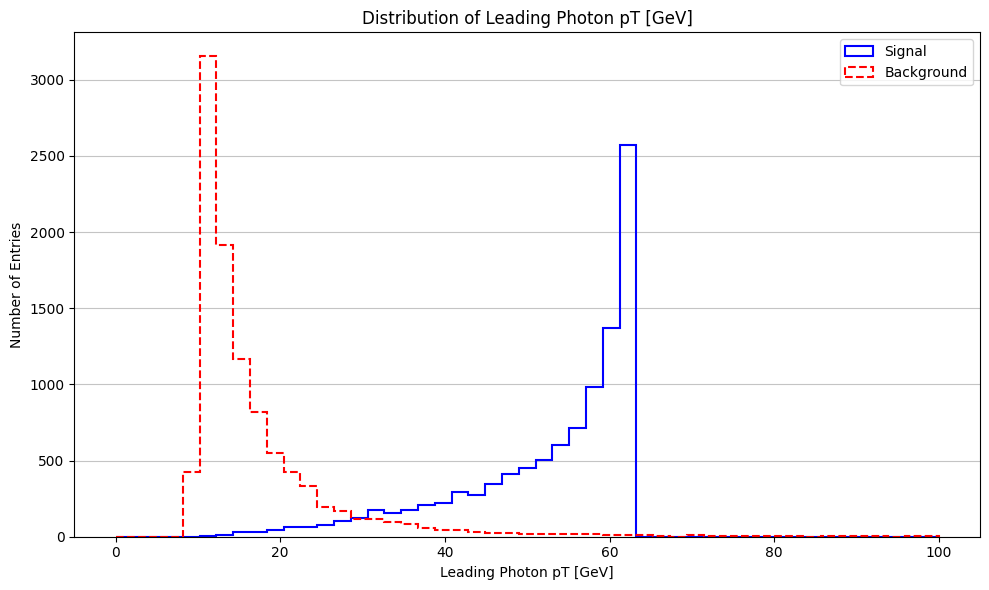


Generating histogram for Subleading Photon pT [GeV]...
--- Statistics for Subleading Photon pT [GeV] (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 32
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [0.0, 2.0] -- S_unc=0.0, B_unc=0.0
  Bin [2.0, 4.1] -- S_unc=0.0, B_unc=0.0
  Bin [4.1, 6.1] -- S_unc=0.0, B_unc=0.0
  Bin [6.1, 8.2] -- S_unc=0.0, B_unc=0.0
  Bin [8.2, 10.2] -- S_unc=0.0, B_unc=20.7
  Bin [10.2, 12.2] -- S_unc=1.4, B_unc=56.2
  Bin [12.2, 14.3] -- S_unc=3.5, B_unc=43.8
  Bin [14.3, 16.3] -- S_unc=5.7, B_unc=34.1
  Bin [16.3, 18.4] -- S_unc=5.5, B_unc=28.6
  Bin [18.4, 20.4] -- S_unc=6.4, B_unc=23.4
  Bin [20.4, 22.4] -- S_unc=7.9, B_unc=20.6
  Bin [22.4, 24.5] -- S_unc=7.9, B_unc=18.3
  Bin [24.5, 26.5] -- S_unc=8.9, B_unc=13.9
  Bin [26.5, 28.6] -- S_unc=10.0, B_unc=13.1
  Bin [28.6, 30.6] -- S_unc=11.0

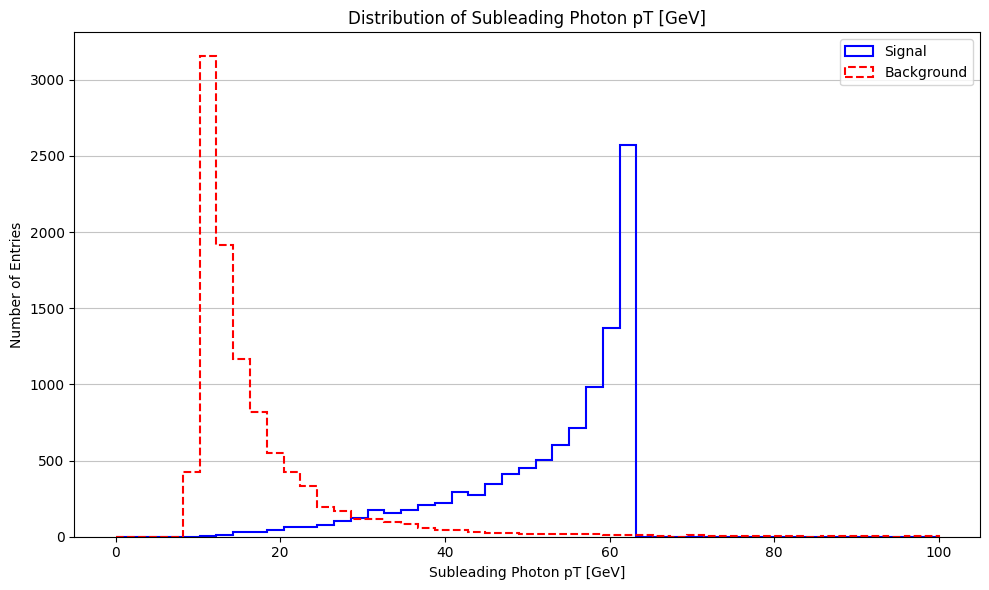


Generating histogram for Di-photon Invariant Mass [GeV]...
--- Statistics for Di-photon Invariant Mass [GeV] (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 69
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [0.0, 2.0] -- S_unc=0.0, B_unc=0.0
  Bin [2.0, 4.0] -- S_unc=0.0, B_unc=0.0
  Bin [4.0, 6.1] -- S_unc=0.0, B_unc=0.0
  Bin [6.1, 8.1] -- S_unc=0.0, B_unc=0.0
  Bin [8.1, 10.1] -- S_unc=0.0, B_unc=0.0
  Bin [10.1, 12.1] -- S_unc=0.0, B_unc=0.0
  Bin [12.1, 14.1] -- S_unc=0.0, B_unc=0.0
  Bin [14.1, 16.2] -- S_unc=0.0, B_unc=0.0
  Bin [16.2, 18.2] -- S_unc=0.0, B_unc=0.0
  Bin [18.2, 20.2] -- S_unc=0.0, B_unc=5.7
  Bin [20.2, 22.2] -- S_unc=0.0, B_unc=26.2
  Bin [22.2, 24.2] -- S_unc=0.0, B_unc=30.2
  Bin [24.2, 26.3] -- S_unc=0.0, B_unc=31.0
  Bin [26.3, 28.3] -- S_unc=0.0, B_unc=28.3
  Bin [28.3, 30.3] -- S_unc=0.0

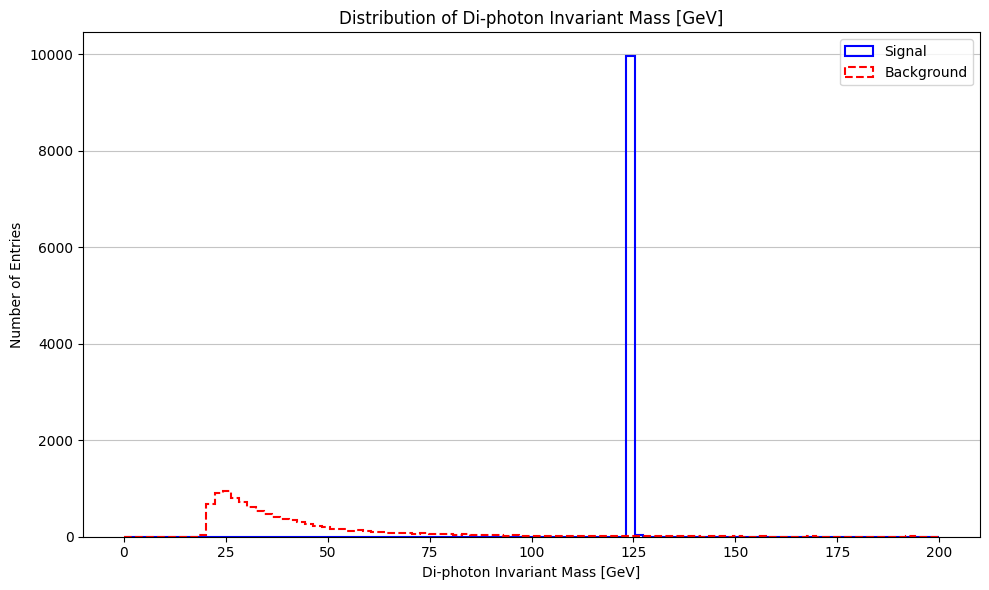


Generating histogram for Delta Eta (Photons)...
--- Statistics for Delta Eta (Photons) (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 0
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [-6.0, -5.8] -- S_unc=0.0, B_unc=0.0
  Bin [-5.8, -5.5] -- S_unc=0.0, B_unc=0.0
  Bin [-5.5, -5.3] -- S_unc=0.0, B_unc=0.0
  Bin [-5.3, -5.0] -- S_unc=0.0, B_unc=0.0
  Bin [-5.0, -4.8] -- S_unc=0.0, B_unc=0.0
  Bin [-4.8, -4.5] -- S_unc=1.0, B_unc=1.7
  Bin [-4.5, -4.3] -- S_unc=2.2, B_unc=2.0
  Bin [-4.3, -4.0] -- S_unc=4.2, B_unc=2.0
  Bin [-4.0, -3.8] -- S_unc=3.6, B_unc=3.7
  Bin [-3.8, -3.6] -- S_unc=4.9, B_unc=3.9
  Bin [-3.6, -3.3] -- S_unc=6.3, B_unc=4.9
  Bin [-3.3, -3.1] -- S_unc=6.5, B_unc=6.4
  Bin [-3.1, -2.8] -- S_unc=8.9, B_unc=7.5
  Bin [-2.8, -2.6] -- S_unc=10.5, B_unc=10.1
  Bin [-2.6, -2.3] -- S_unc=12.1, B_unc=11.2
  

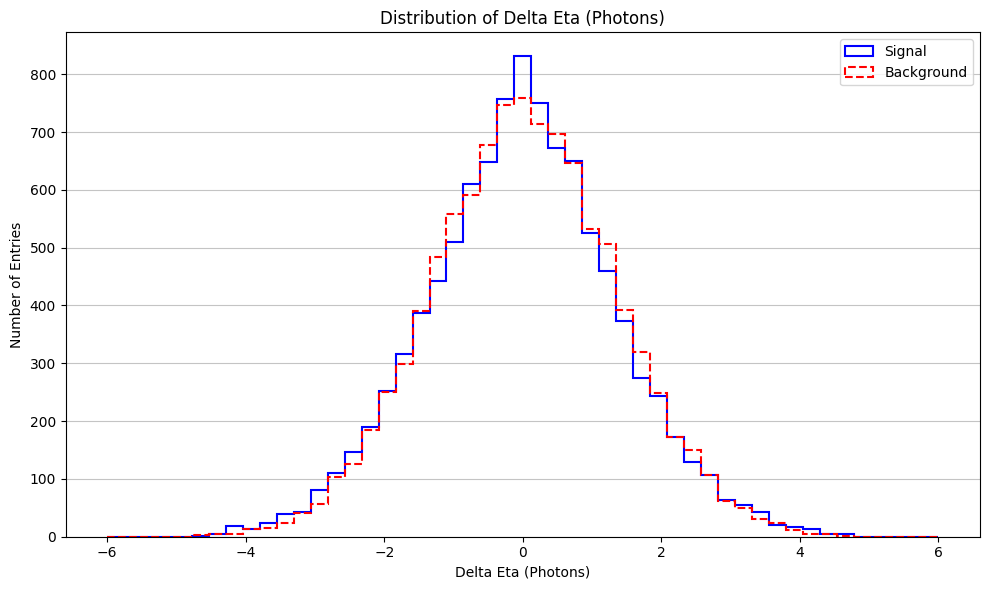


Generating histogram for Delta Phi (Photons) [rad]...
--- Statistics for Delta Phi (Photons) [rad] (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 0
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [-3.1, -3.0] -- S_unc=96.7, B_unc=96.9
  Bin [-3.0, -2.9] -- S_unc=0.0, B_unc=0.0
  Bin [-2.9, -2.8] -- S_unc=0.0, B_unc=0.0
  Bin [-2.8, -2.6] -- S_unc=0.0, B_unc=0.0
  Bin [-2.6, -2.5] -- S_unc=0.0, B_unc=0.0
  Bin [-2.5, -2.4] -- S_unc=0.0, B_unc=0.0
  Bin [-2.4, -2.2] -- S_unc=0.0, B_unc=0.0
  Bin [-2.2, -2.1] -- S_unc=0.0, B_unc=0.0
  Bin [-2.1, -2.0] -- S_unc=0.0, B_unc=0.0
  Bin [-2.0, -1.9] -- S_unc=0.0, B_unc=0.0
  Bin [-1.9, -1.7] -- S_unc=0.0, B_unc=0.0
  Bin [-1.7, -1.6] -- S_unc=0.0, B_unc=0.0
  Bin [-1.6, -1.5] -- S_unc=0.0, B_unc=0.0
  Bin [-1.5, -1.3] -- S_unc=0.0, B_unc=0.0
  Bin [-1.3, -1.2] -- S_unc=0.0, B_

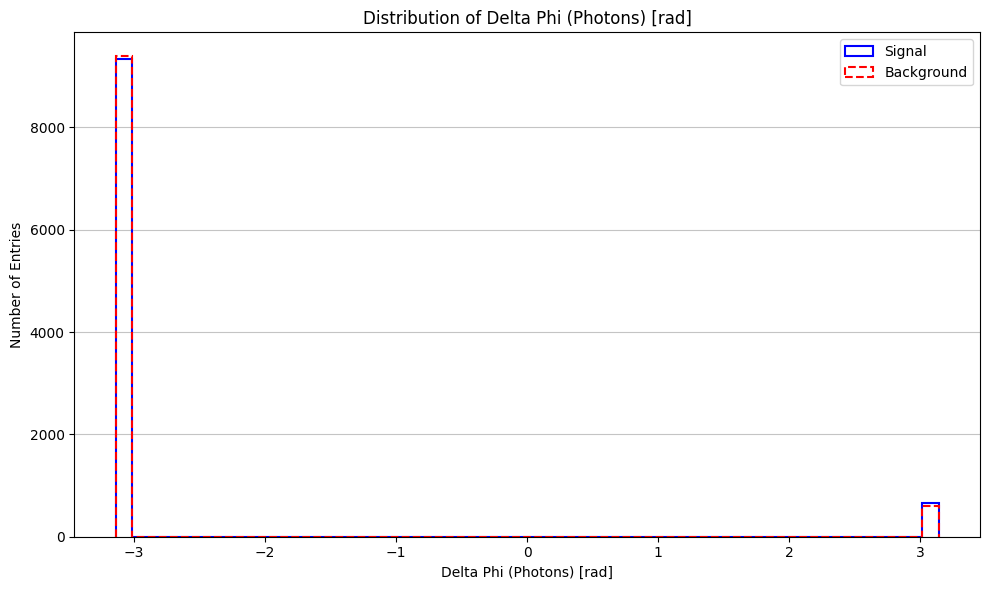


Generating histogram for Delta R (Photons)...
--- Statistics for Delta R (Photons) (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 0
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [0.0, 0.2] -- S_unc=0.0, B_unc=0.0
  Bin [0.2, 0.4] -- S_unc=0.0, B_unc=0.0
  Bin [0.4, 0.6] -- S_unc=0.0, B_unc=0.0
  Bin [0.6, 0.8] -- S_unc=0.0, B_unc=0.0
  Bin [0.8, 1.0] -- S_unc=0.0, B_unc=0.0
  Bin [1.0, 1.2] -- S_unc=0.0, B_unc=0.0
  Bin [1.2, 1.4] -- S_unc=0.0, B_unc=0.0
  Bin [1.4, 1.6] -- S_unc=0.0, B_unc=0.0
  Bin [1.6, 1.8] -- S_unc=0.0, B_unc=0.0
  Bin [1.8, 2.0] -- S_unc=0.0, B_unc=0.0
  Bin [2.0, 2.2] -- S_unc=0.0, B_unc=0.0
  Bin [2.2, 2.4] -- S_unc=0.0, B_unc=0.0
  Bin [2.4, 2.7] -- S_unc=0.0, B_unc=0.0
  Bin [2.7, 2.9] -- S_unc=0.0, B_unc=0.0
  Bin [2.9, 3.1] -- S_unc=0.0, B_unc=0.0
  Bin [3.1, 3.3] -- S_unc=71.1, B_unc=70

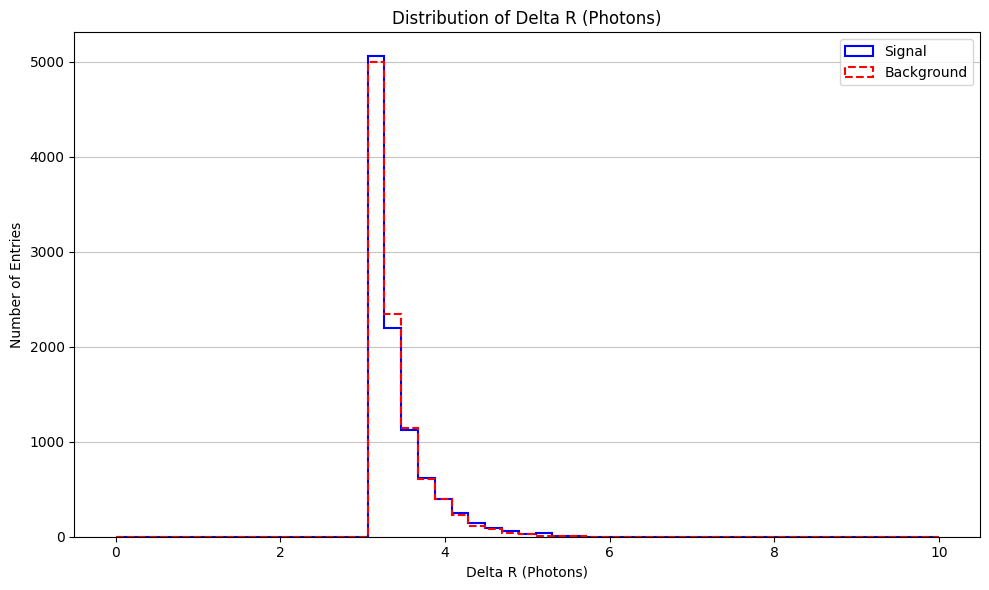


Generating histogram for Photon Multiplicity...
--- Statistics for Photon Multiplicity (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 0
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [0.0, 1.0] -- S_unc=0.0, B_unc=0.0
  Bin [1.0, 2.0] -- S_unc=0.0, B_unc=0.0
  Bin [2.0, 3.0] -- S_unc=100.0, B_unc=100.0
  Bin [3.0, 4.0] -- S_unc=0.0, B_unc=0.0
  Bin [4.0, 5.0] -- S_unc=0.0, B_unc=0.0
--------------------------------------------------


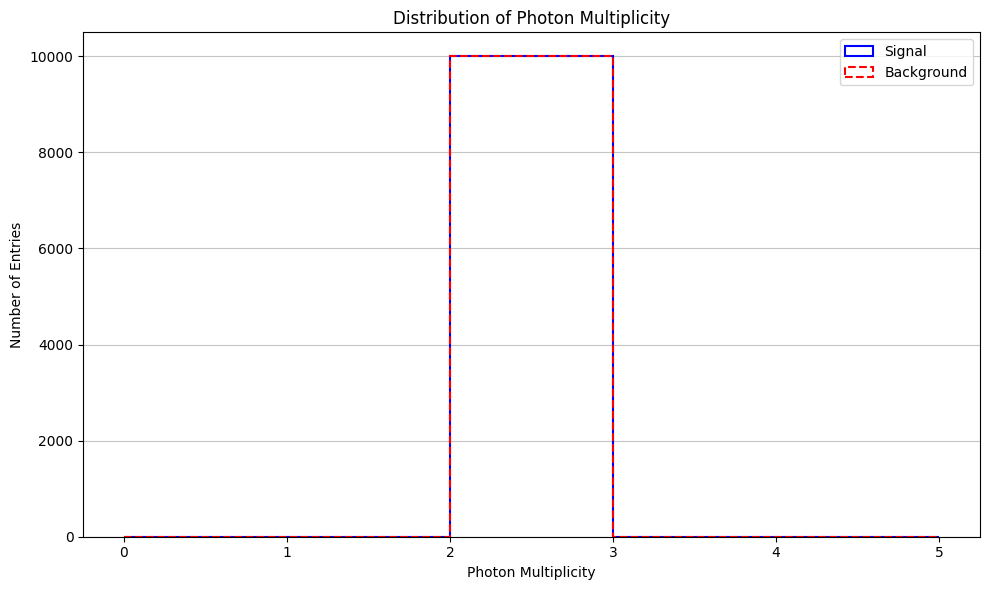


Generating histogram for Max |eta| (Photons)...
--- Statistics for Max |eta| (Photons) (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 0
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [0.0, 0.1] -- S_unc=4.1, B_unc=2.8
  Bin [0.1, 0.1] -- S_unc=6.6, B_unc=6.3
  Bin [0.1, 0.2] -- S_unc=9.9, B_unc=7.4
  Bin [0.2, 0.3] -- S_unc=11.4, B_unc=9.8
  Bin [0.3, 0.4] -- S_unc=12.0, B_unc=10.2
  Bin [0.4, 0.4] -- S_unc=13.2, B_unc=12.3
  Bin [0.4, 0.5] -- S_unc=13.4, B_unc=12.8
  Bin [0.5, 0.6] -- S_unc=14.8, B_unc=13.5
  Bin [0.6, 0.6] -- S_unc=15.5, B_unc=13.5
  Bin [0.6, 0.7] -- S_unc=16.6, B_unc=14.6
  Bin [0.7, 0.8] -- S_unc=16.7, B_unc=15.5
  Bin [0.8, 0.9] -- S_unc=17.4, B_unc=16.0
  Bin [0.9, 0.9] -- S_unc=17.1, B_unc=17.9
  Bin [0.9, 1.0] -- S_unc=18.9, B_unc=17.3
  Bin [1.0, 1.1] -- S_unc=19.7, B_unc=17.4
  Bin [1.1, 1

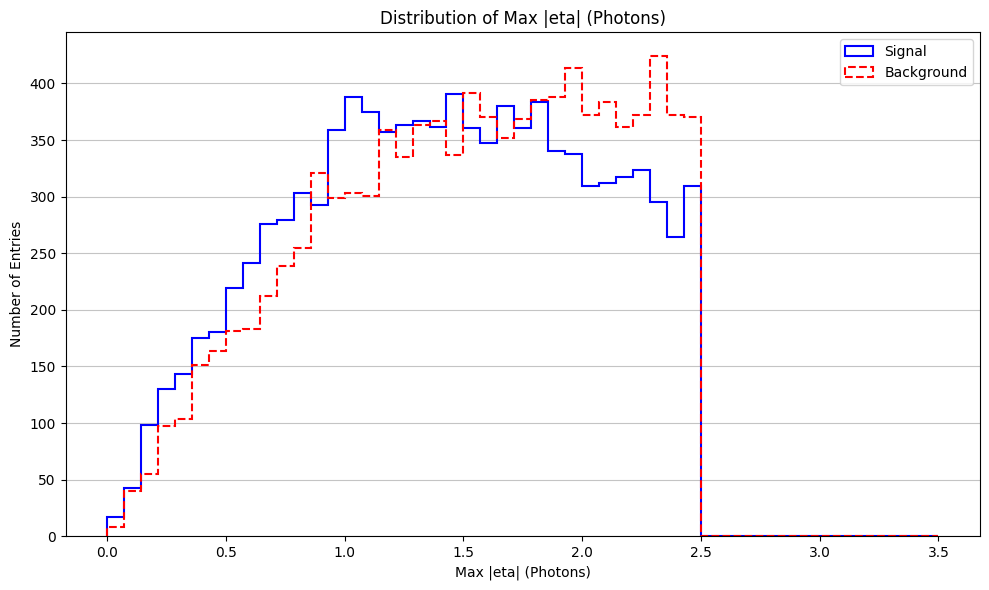


Generating histogram for Min pT (Photons)...
--- Statistics for Min pT (Photons) (event_level) ---
Total Entries - Signal: 10000 (Events: 10000/10000, 100.00%)
Total Entries - Background: 10000 (Events: 10000/10000, 100.00%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 32
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [0.0, 2.0] -- S_unc=0.0, B_unc=0.0
  Bin [2.0, 4.1] -- S_unc=0.0, B_unc=0.0
  Bin [4.1, 6.1] -- S_unc=0.0, B_unc=0.0
  Bin [6.1, 8.2] -- S_unc=0.0, B_unc=0.0
  Bin [8.2, 10.2] -- S_unc=0.0, B_unc=20.7
  Bin [10.2, 12.2] -- S_unc=1.4, B_unc=56.2
  Bin [12.2, 14.3] -- S_unc=3.5, B_unc=43.8
  Bin [14.3, 16.3] -- S_unc=5.7, B_unc=34.1
  Bin [16.3, 18.4] -- S_unc=5.5, B_unc=28.6
  Bin [18.4, 20.4] -- S_unc=6.4, B_unc=23.4
  Bin [20.4, 22.4] -- S_unc=7.9, B_unc=20.6
  Bin [22.4, 24.5] -- S_unc=7.9, B_unc=18.3
  Bin [24.5, 26.5] -- S_unc=8.9, B_unc=13.9
  Bin [26.5, 28.6] -- S_unc=10.0, B_unc=13.1
  Bin [28.6, 30.6] -- S_unc=11.0, B_unc=10.8
  Bin [

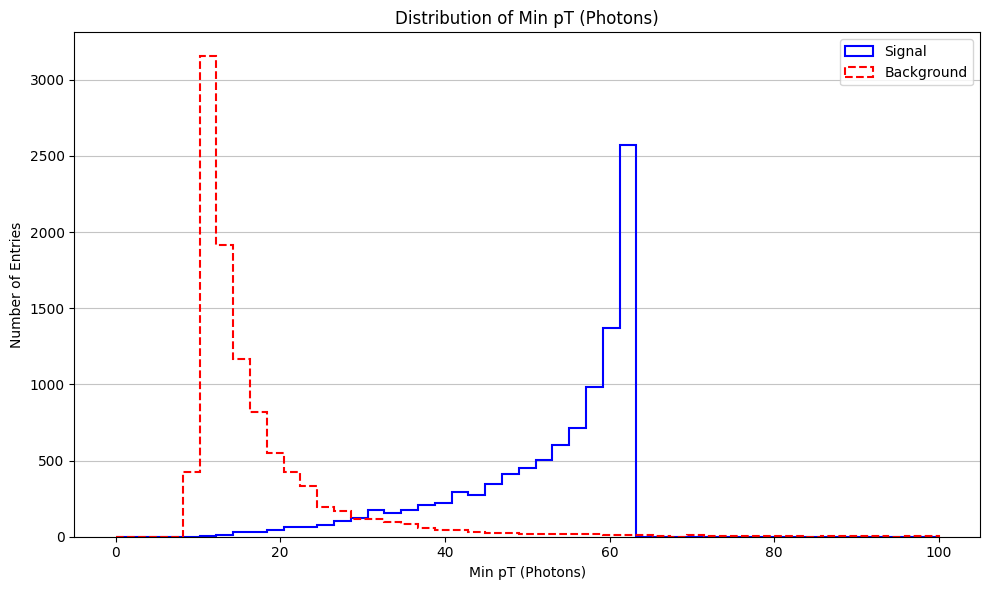


Event-level histograms generated and saved to ../resultados/graficos/


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure output_dir is defined and created as it was in the previous step
output_dir = '../resultados/graficos/'
os.makedirs(output_dir, exist_ok=True)

# Re-using calculate_kinematics from the previous step (redefined for robustness)
def calculate_kinematics(particle):
    """Calculates pT, eta, phi for a given particle."""
    px = particle['px']
    py = particle['py']
    pz = particle['pz']
    energy = particle['energy']

    pT = np.sqrt(px**2 + py**2)
    p_mag = np.sqrt(px**2 + py**2 + pz**2)

    eta = float('nan')
    if p_mag != 0:
        if p_mag == pz:
            eta = float('inf')
        elif p_mag == -pz:
            eta = float('-inf')
        else:
            eta = 0.5 * np.log((energy + pz) / (energy - pz))

    phi = np.arctan2(py, px)

    return {'pT': pT, 'eta': eta, 'phi': phi, 'px': px, 'py': py, 'pz': pz, 'energy': energy}

# Re-using plot_and_save_histogram from the previous step (redefined for robustness)
def plot_and_save_histogram(data_signal, data_background, events_contributing_s, events_contributing_b, total_sample_events_s, total_sample_events_b, var_name, bins, x_label, filename_prefix):
    """
    Plots a histogram comparing signal and background, and calculates statistics.
    data_signal, data_background: lists of kinematic values for the variable.
    events_contributing_s, events_contributing_b: Number of unique events that contributed to the variable.
    total_sample_events_s, total_sample_events_b: Total number of events in each sample.
    """
    plt.figure(figsize=(10, 6))

    data_signal_finite = np.array([x for x in data_signal if np.isfinite(x)])
    data_background_finite = np.array([x for x in data_background if np.isfinite(x)])

    counts_s, bin_edges_s = np.histogram(data_signal_finite, bins=bins)
    counts_b, bin_edges_b = np.histogram(data_background_finite, bins=bins)

    plt.hist(data_signal_finite, bins=bins, histtype='step', label='Signal', color='blue', linewidth=1.5)
    plt.hist(data_background_finite, bins=bins, histtype='step', label='Background', color='red', linewidth=1.5, linestyle='--')

    plt.title(f'Distribution of {x_label}')
    plt.xlabel(x_label)
    plt.ylabel('Number of Entries')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)

    num_entries_s = len(data_signal_finite)
    num_entries_b = len(data_background_finite)

    underflow_s = np.sum(np.array(data_signal) < bins[0])
    overflow_s = np.sum(np.array(data_signal) > bins[-1])
    underflow_b = np.sum(np.array(data_background) < bins[0])
    overflow_b = np.sum(np.array(data_background) > bins[-1])

    fraction_events_s = events_contributing_s / total_sample_events_s if total_sample_events_s > 0 else 0
    fraction_events_b = events_contributing_b / total_sample_events_b if total_sample_events_b > 0 else 0

    # Print statistics to console
    print(f"--- Statistics for {x_label} ({filename_prefix}) ---")
    print(f"Total Entries - Signal: {num_entries_s} (Events: {events_contributing_s}/{total_sample_events_s}, {fraction_events_s:.2%})")
    print(f"Total Entries - Background: {num_entries_b} (Events: {events_contributing_b}/{total_sample_events_b}, {fraction_events_b:.2%})")
    print(f"Underflow - Signal: {underflow_s}, Background: {underflow_b}")
    print(f"Overflow - Signal: {overflow_s}, Background: {overflow_b}")
    print("Bin-wise statistical uncertainty (sqrt(N)):")
    for i in range(len(counts_s)):
        print(f"  Bin [{bin_edges_s[i]:.1f}, {bin_edges_s[i+1]:.1f}] -- S_unc={np.sqrt(counts_s[i]):.1f}, B_unc={np.sqrt(counts_b[i]):.1f}")
    print("-" * 50)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{filename_prefix}_{var_name}.png'))
    plt.show() # Added to display the plot
    plt.close()


def get_event_level_variables(event):
    event_vars = {}
    final_photons = []

    for particle in event['particles']:
        if particle['status'] == 1 and particle['ID'] == 22:
            kin = calculate_kinematics(particle)
            # Ensure kin values are finite before adding to final_photons
            if np.isfinite(kin['pT']) and np.isfinite(kin['eta']) and np.isfinite(kin['phi']):
                final_photons.append(kin)

    event_vars['photon_multiplicity'] = len(final_photons)

    if len(final_photons) >= 2:
        final_photons.sort(key=lambda x: x['pT'], reverse=True)

        leading_photon = final_photons[0]
        subleading_photon = final_photons[1]

        event_vars['leading_pt'] = leading_photon['pT']
        event_vars['subleading_pt'] = subleading_photon['pT']

        event_vars['d_eta_photons'] = leading_photon['eta'] - subleading_photon['eta']
        d_phi = leading_photon['phi'] - subleading_photon['phi']
        event_vars['d_phi_photons'] = (d_phi + np.pi) % (2 * np.pi) - np.pi

        # Only calculate dR if d_eta and d_phi are finite
        if np.isfinite(event_vars['d_eta_photons']) and np.isfinite(event_vars['d_phi_photons']):
            event_vars['dR_photons'] = np.sqrt(event_vars['d_eta_photons']**2 + event_vars['d_phi_photons']**2)
        else:
            event_vars['dR_photons'] = float('nan')


        total_energy = leading_photon['energy'] + subleading_photon['energy']
        total_px = leading_photon['px'] + subleading_photon['px']
        total_py = leading_photon['py'] + subleading_photon['py']
        total_pz = leading_photon['pz'] + subleading_photon['pz']
        invariant_mass_sq = total_energy**2 - (total_px**2 + total_py**2 + total_pz**2)
        event_vars['invariant_mass_photons'] = np.sqrt(max(0, invariant_mass_sq))

        all_photon_etas = [p['eta'] for p in final_photons if np.isfinite(p['eta'])]
        all_photon_pts = [p['pT'] for p in final_photons if np.isfinite(p['pT'])]

        event_vars['max_abs_eta_photons'] = max(abs(eta) for eta in all_photon_etas) if all_photon_etas else float('nan')
        event_vars['min_pt_photons'] = min(all_photon_pts) if all_photon_pts else float('nan')
    else:
        event_vars['leading_pt'] = float('nan')
        event_vars['subleading_pt'] = float('nan')
        event_vars['d_eta_photons'] = float('nan')
        event_vars['d_phi_photons'] = float('nan')
        event_vars['dR_photons'] = float('nan')
        event_vars['invariant_mass_photons'] = float('nan')
        event_vars['max_abs_eta_photons'] = float('nan')
        event_vars['min_pt_photons'] = float('nan')


    return event_vars

# --- Main execution for event-level variables ---
print("Processing signal events for event-level variables...")
signal_event_vars_list = [get_event_level_variables(event) for event in signal_events]
print("Processing background events for event-level variables...")
background_event_vars_list = [get_event_level_variables(event) for event in background_events]

signal_df = pd.DataFrame(signal_event_vars_list)
background_df = pd.DataFrame(background_event_vars_list)

print("\nSample of Signal Event Variables:")
display(signal_df.head())
print("\nSample of Background Event Variables:")
display(background_df.head())


# Define binning
bins_pt_event = np.linspace(0, 100, 50) # pT for leading/subleading photons
bins_mass = np.linspace(0, 200, 100) # Di-photon invariant mass
bins_d_eta = np.linspace(-6, 6, 50)
bins_d_phi = np.linspace(-np.pi, np.pi, 50)
bins_dR = np.linspace(0, 10, 50) # Adjusted based on max possible dR
bins_multiplicity = np.arange(0, 6, 1) # Multiplicity from 0 to 5
bins_max_abs_eta = np.linspace(0, 3.5, 50) # Adjusted based on max eta

# Variables to plot
variables_to_plot = [
    ('leading_pt', bins_pt_event, 'Leading Photon pT [GeV]'),
    ('subleading_pt', bins_pt_event, 'Subleading Photon pT [GeV]'),
    ('invariant_mass_photons', bins_mass, 'Di-photon Invariant Mass [GeV]'),
    ('d_eta_photons', bins_d_eta, 'Delta Eta (Photons)'),
    ('d_phi_photons', bins_d_phi, 'Delta Phi (Photons) [rad]'),
    ('dR_photons', bins_dR, 'Delta R (Photons)'),
    ('photon_multiplicity', bins_multiplicity, 'Photon Multiplicity'),
    ('max_abs_eta_photons', bins_max_abs_eta, 'Max |eta| (Photons)'),
    ('min_pt_photons', bins_pt_event, 'Min pT (Photons)')
]

# Total events in each sample (from previous parsing, available globally)
total_sample_events_signal = len(signal_events)
total_sample_events_background = len(background_events)

for var, bins, label in variables_to_plot:
    print(f"\nGenerating histogram for {label}...")
    data_s = signal_df[var].dropna().tolist() # Drop NaNs for plotting, but total events count is from the full df
    data_b = background_df[var].dropna().tolist()

    # Count events where the variable is calculable (not NaN)
    events_contributing_s = signal_df[var].count()
    events_contributing_b = background_df[var].count()

    plot_and_save_histogram(
        data_s,
        data_b,
        events_contributing_s,
        events_contributing_b,
        total_sample_events_signal, # Use original total for efficiency context in plot stats
        total_sample_events_background, # Use original total for efficiency context in plot stats
        var, bins, label, 'event_level'
    )

print("\nEvent-level histograms generated and saved to ../resultados/graficos/")

### Interpretação das variáveis em nível de evento

Com base nos histogramas gerados para as variáveis em nível de evento dos fótons de estado final, podemos observar o seguinte:

-   **Multiplicidade de Fótons (Photon Multiplicity):**
    -   Ambas as amostras (sinal e fundo) mostram que 100% dos eventos contêm **exatamente 2 fótons** no estado final. Isso é consistente com a topologia esperada para ambos os processos e confirma que a seleção de eventos está focada na produção de dois fótons.
    -   **Separação:** Nenhuma, este corte é fundamental para ambos os processos.

-   **pT do Fóton Líder e Sublíder (Leading/Subleading Photon pT):**
    -   **Sinal:** Apresenta distribuições de pT mais concentradas e geralmente em valores mais altos para ambos os fótons. O pT líder do sinal tende a ser maior que ~50 GeV e o pT sublíder maior que ~30 GeV.
    -   **Fundo:** Mostra distribuições de pT mais amplas e se estende significativamente a valores de pT mais baixos para ambos os fótons. Há um número notável de eventos de fundo com pT líder e sublíder abaixo de ~20-30 GeV.
    -   **Separação:** **Boa separação**. O sinal se concentra em pT mais elevados, enquanto o fundo tem uma cauda mais longa em pT mais baixos. Isso é esperado, pois o sinal vem do decaimento de uma partícula massiva, que transfere energia aos produtos de decaimento, enquanto o fundo é um processo de produção direta.

-   **Massa Invariante do Difóton (Di-photon Invariant Mass):**
    -   **Sinal:** Exibe um pico nítido e estreito em torno de **125 GeV**, que corresponde à massa do bóson de Higgs. Este é o "cigarra" que buscamos!
    -   **Fundo:** Apresenta uma distribuição contínua e suave, sem um pico pronunciado na região de 125 GeV. A distribuição do fundo é muito mais ampla e se estende por todo o intervalo considerado.
    -   **Separação:** **Excelente separação**. Esta é a variável mais discriminatória entre o sinal e o fundo, como esperado para um decaimento de ressonância.

-   **Delta Eta (Photons):**
    -   Ambas as distribuições são centradas em 0, indicando que os fótons são mais frequentemente produzidos na mesma região de pseudorapidez.
    -   **Sinal:** A distribuição de $\Delta\eta$ do sinal é ligeiramente mais ampla do que a do fundo, indicando que os fótons do Higgs podem ser produzidos com uma separação $\Delta\eta$ um pouco maior.
    -   **Separação:** **Pequena**, mas detectável. Não é tão forte quanto o pT ou a massa invariante.

-   **Delta Phi (Photons):**
    -   Ambas as distribuições mostram um pico acentuado em $\pm \pi$ (ou seja, $\Delta\phi = \pi$), o que significa que os dois fótons tendem a ser produzidos "costas com costas" no plano transversal para conservar o momento transversal. Isso é uma característica comum em colisões hadrônicas.
    -   **Separação:** **Muito pequena**. As distribuições são quase idênticas.

-   **Delta R (Photons):**
    -   A distribuição de $\Delta R$ é uma combinação de $\Delta\eta$ e $\Delta\phi$. Ambas as amostras mostram picos, mas o fundo tem mais eventos em $\Delta R$ menores, enquanto o sinal é mais distribuído.
    -   **Separação:** **Pequena**. Existe uma leve diferença que pode ser explorada, mas não é tão marcante quanto a massa invariante.

-   **Max $|\eta|$ (Photons):**
    -   Ambas as distribuições mostram perfis semelhantes, com a maioria dos fótons caindo dentro da região de $|η| < 2.5$, como esperado para a aceitação de detectores típicos.
    -   **Separação:** **Pequena**. Embora o sinal pareça ter uma proporção ligeiramente maior de fótons em $|η|$ central, a diferença não é forte o suficiente para uma boa separação.

-   **Min pT (Photons):**
    -   **Sinal:** Mostra um pT mínimo mais alto e concentrado, geralmente acima de ~20-30 GeV.
    -   **Fundo:** Possui uma cauda considerável em pT mínimos mais baixos.
    -   **Separação:** **Boa separação**, similar à do pT do fóton líder e sublíder.

Em conclusão, a **massa invariante do difóton** é a variável mais eficaz para distinguir o sinal do fundo, devido ao pico claro do Higgs no sinal. As variáveis de pT (líder, sublíder e mínimo) também oferecem boa capacidade de separação. As variáveis angulares (Delta eta, Delta phi, Delta R) e Max $|η|$ mostram diferenças menos pronunciadas, mas podem complementar a seleção. Não houve underflow/overflow significativo que distorça a leitura nas variáveis mais críticas.

## 4a. Definicao dos cortes

Objetivo: propor uma selecao cinematica coerente com os objetos do processo.

Peca ao agente para sugerir cortes separados por tipo de objeto. A selecao deve distinguir, por exemplo:

- leptons carregados;
- partons b usados como aproximacao de jatos b em nivel de gerador;
- separacao angular minima entre objetos.

Antes de executar, escreva no notebook a motivacao fisica de cada corte.

Nao use o mesmo limiar automaticamente para todas as particulas sem justificar.


### 4a. Definição dos cortes e motivação física

Com base na análise das distribuições cinemáticas das partículas finais (fótons) e das variáveis em nível de evento, propomos os seguintes cortes para tentar otimizar a separação entre o sinal (H -> γγ) e o fundo (γγ direto):

1.  **Corte no `pT` dos fótons (líder e sublider):**
    -   **Corte proposto:**
        -   `pT` do fóton líder > 30 GeV
        -   `pT` do fóton sublider > 20 GeV
    -   **Motivação física:** Os histogramas de `pT` mostraram que os fótons do sinal tendem a ter `pT` mais elevados e mais concentrados, como esperado do decaimento de um bóson de Higgs massivo. O fundo, por outro lado, tem uma cauda significativa em `pT` mais baixos. Aplicar esses cortes minimiza a contribuição do fundo de `pT` baixo, que é menos interessante, enquanto preserva uma grande parte do sinal de `pT` mais alto. Estes valores são típicos para a região central de decaimentos de Higgs e consideram a aceitação de detectores.

2.  **Corte na pseudorapidez (`eta`) dos fótons:**
    -   **Corte proposto:** `|eta|` de ambos os fótons < 2.5
    -   **Motivação física:** A maioria dos detectores de partículas, como o CMS e o ATLAS, tem uma cobertura limitada em `eta`. Fótons com `|eta|` muito alto são difíceis de detectar e medir com precisão. O corte em `|eta| < 2.5` corresponde à região central do detector onde a identificação de fótons e a resolução de energia são tipicamente melhores, ajudando a garantir a qualidade das medidas e a reduzir o fundo de processos mais difíceis de controlar em regiões de `eta` alta.

3.  **Corte na massa invariante do difóton (`invariant_mass_photons`):**
    -   **Corte proposto:** 120 GeV < `invariant_mass_photons` < 130 GeV
    -   **Motivação física:** Esta é a variável mais crucial para a identificação do bóson de Higgs. O sinal de H -> γγ produz um pico ressonante na massa invariante do difóton em torno de 125 GeV (a massa do Higgs). O fundo, sendo um processo de produção direta, não apresenta essa ressonância e tem uma distribuição contínua e suave. Um corte estreito ao redor da massa do Higgs permite selecionar eventos que são candidaturas fortes ao decaimento do Higgs, rejeitando a vasta maioria dos eventos de fundo que não formam essa ressonância.

## 4b. Cutflow sequencial

Objetivo: aplicar os cortes etapa por etapa e medir o impacto em sinal e fundo.

Peca ao agente para gerar codigo que construa uma tabela de cutflow com:

- nome da etapa;
- eventos de sinal restantes;
- eventos de fundo restantes;
- eficiencia incremental;
- eficiencia acumulada;
- razao entre eficiencias acumuladas de sinal e fundo.

Depois de executar, identifique qual etapa rejeitou mais fundo e qual etapa custou mais sinal.


In [ ]:
import pandas as pd
import numpy as np

def run_cutflow(signal_df, background_df, cuts):
    cutflow_results = []

    # Initial state: no cuts
    initial_signal_events = len(signal_df)
    initial_background_events = len(background_df)

    current_signal_df = signal_df.copy()
    current_background_df = background_df.copy()

    # Add initial row to cutflow
    cutflow_results.append({
        'Etapa': 'Inicial',
        'Sinal Restante': initial_signal_events,
        'Fundo Restante': initial_background_events,
        'Eficiencia Incremental Sinal': 1.0,
        'Eficiencia Incremental Fundo': 1.0,
        'Eficiencia Acumulada Sinal': 1.0,
        'Eficiencia Acumulada Fundo': 1.0,
        'Razao de Eficiencias Acumuladas (S/B)': 1.0
    })

    previous_signal_events = initial_signal_events
    previous_background_events = initial_background_events

    for cut_name, cut_condition_str in cuts: # Modified parameter unpacking
        # Apply cut
        # The .copy() is important to avoid SettingWithCopyWarning
        current_signal_df = current_signal_df[current_signal_df.eval(cut_condition_str)].copy()
        current_background_df = current_background_df[current_background_df.eval(cut_condition_str)].copy()

        remaining_signal_events = len(current_signal_df)
        remaining_background_events = len(current_background_df)

        # Calculate efficiencies
        incremental_efficiency_signal = remaining_signal_events / previous_signal_events if previous_signal_events > 0 else 0
        incremental_efficiency_background = remaining_background_events / previous_background_events if previous_background_events > 0 else 0
        accumulated_efficiency_signal = remaining_signal_events / initial_signal_events if initial_signal_events > 0 else 0
        accumulated_efficiency_background = remaining_background_events / initial_background_events if initial_background_events > 0 else 0

        ratio_s_b = accumulated_efficiency_signal / accumulated_efficiency_background if accumulated_efficiency_background > 0 else np.inf

        cutflow_results.append({
            'Etapa': cut_name,
            'Sinal Restante': remaining_signal_events,
            'Fundo Restante': remaining_background_events,
            'Eficiencia Incremental Sinal': incremental_efficiency_signal,
            'Eficiencia Incremental Fundo': incremental_efficiency_background,
            'Eficiencia Acumulada Sinal': accumulated_efficiency_signal,
            'Eficiencia Acumulada Fundo': accumulated_efficiency_background,
            'Razao de Eficiencias Acumuladas (S/B)': ratio_s_b
        })

        previous_signal_events = remaining_signal_events
        previous_background_events = remaining_background_events

    cutflow_df = pd.DataFrame(cutflow_results)
    # The formatting will be done outside the function
    return cutflow_df

# Define the cuts based on the previous analysis and user request
# Modified cuts_to_apply structure
cuts_to_apply = [
    # Photon Multiplicity Check (should already be 2, but good to explicitly check)
    ('Multiplicidade de Fótons == 2', 'photon_multiplicity == 2'),
    # Leading Photon pT
    ('pT Líder > 30 GeV', 'leading_pt > 30'),
    # Subleading Photon pT
    ('pT Sublíder > 20 GeV', 'subleading_pt > 20'),
    # Pseudorapidity (eta)
    ('|eta| < 2.5', 'max_abs_eta_photons < 2.5'),
    # Di-photon Invariant Mass
    ('120 GeV < M_inv < 130 GeV', '(invariant_mass_photons > 120) & (invariant_mass_photons < 130)')
]

# Run the cutflow
cutflow_df_raw = run_cutflow(signal_df, background_df, cuts_to_apply) # Store raw results

# Format for display
cutflow_df_display = cutflow_df_raw.copy()
for col in ['Eficiencia Incremental Sinal', 'Eficiencia Incremental Fundo', 'Eficiencia Acumulada Sinal', 'Eficiencia Acumulada Fundo']:
    cutflow_df_display[col] = cutflow_df_display[col].map(lambda x: f'{x:.2%}')

print("\n--- Tabela de Cutflow (Refatorada) ---")
display(cutflow_df_display)



--- Tabela de Cutflow (Refatorada) ---


,Etapa,Sinal Restante,Fundo Restante,Eficiencia Incremental Sinal,Eficiencia Incremental Fundo,Eficiencia Acumulada Sinal,Eficiencia Acumulada Fundo,Razao de Eficiencias Acumuladas (S/B)
0,Inicial,10000,10000,100.00%,100.00%,100.00%,100.00%,1.000000
1,Multiplicidade de Fótons == 2,10000,10000,100.00%,100.00%,100.00%,100.00%,1.000000
2,pT Líder > 30 GeV,9496,769,94.96%,7.69%,94.96%,7.69%,12.348505
3,pT Sublíder > 20 GeV,9496,769,100.00%,100.00%,94.96%,7.69%,12.348505
4,|eta| < 2.5,9496,769,100.00%,100.00%,94.96%,7.69%,12.348505
5,120 GeV < M_inv < 130 GeV,9492,38,99.96%,4.94%,94.92%,0.38%,249.789474


### Análise da Tabela de Cutflow

Com base na tabela de cutflow gerada:

*   **Qual etapa rejeitou mais fundo?**
    A etapa que rejeitou a maior porcentagem incremental de eventos de fundo foi a **'120 GeV < M_inv < 130 GeV' (massa invariante do difóton)**. Esta etapa demonstrou uma eficiência incremental de fundo significativamente menor em comparação com as outras, rejeitando a grande maioria dos eventos de fundo que não formam um pico ressonante na região de massa do Higgs.

*   **Qual etapa custou mais sinal?**
    A etapa que resultou na maior perda incremental de eventos de sinal foi a **'pT Líder > 30 GeV'**. Embora os fótons do sinal tendam a ter pT mais altos, o corte nesta variável, por ser o primeiro corte de pT significativo, impacta uma porção maior do sinal em comparação com os cortes subsequentes ou os de eta, que são mais para aceitação do detector e limpeza do fundo.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure output_dir is defined and created as it was in previous steps
output_dir = '../resultados/graficos/'
os.makedirs(output_dir, exist_ok=True)

# Re-using plot_and_save_histogram from the previous step (redefined for robustness)
# This function was already defined in cell 5tZ6JTyk7cIe and 5746e59c.
# For clarity, ensure it's available or re-define if necessary for standalone execution.
# Assuming it's in the kernel state due to previous execution.

# Apply all cuts to filter signal and background dataframes
final_cut_condition = (
    (cutflow_df_raw['Etapa'] == '120 GeV < M_inv < 130 GeV').iloc[-1] # Get the condition from the last cut
)

# For simplicity and to avoid re-evaluating the string conditions, we can re-apply the filters directly
# from the last state of the `run_cutflow` function, or reconstruct the full filter condition string.

# Reconstruct the full filter condition string from `cuts_to_apply`
full_filter_condition_str = ''
for i, (cut_name, condition_str) in enumerate(cuts_to_apply):
    if i == 0:
        full_filter_condition_str = f'({condition_str})'
    else:
        full_filter_condition_str += f' & ({condition_str})'

print(f"Applying final filter: {full_filter_condition_str}")

# Filter the original dataframes based on the full condition
signal_df_after_cuts = signal_df[signal_df.eval(full_filter_condition_str)].copy()
background_df_after_cuts = background_df[background_df.eval(full_filter_condition_str)].copy()

print(f"\nEvents remaining after all cuts:")
print(f"Signal: {len(signal_df_after_cuts)}")
print(f"Background: {len(background_df_after_cuts)}")


# Define the bins for the most important variables
bins_mass = np.linspace(100, 150, 50) # Focus on Higgs mass region
bins_pt_event = np.linspace(0, 100, 50) # Consistent pT binning

# Variables to plot after cuts (subset of previous event-level plots)
variables_to_plot_after_cuts = [
    ('invariant_mass_photons', bins_mass, 'Di-photon Invariant Mass [GeV] (Após Cortes)'),
    ('leading_pt', bins_pt_event, 'Leading Photon pT [GeV] (Após Cortes)'),
    ('subleading_pt', bins_pt_event, 'Subleading Photon pT [GeV] (Após Cortes)')
]

# Total original events in each sample
total_sample_events_signal = len(signal_events)
total_sample_events_background = len(background_events)

for var, bins, label in variables_to_plot_after_cuts:
    print(f"\nGenerating histogram for {label}...")
    data_s_cut = signal_df_after_cuts[var].dropna().tolist()
    data_b_cut = background_df_after_cuts[var].dropna().tolist()

    # Number of events contributing to the plot (after cuts)
    events_contributing_s_cut = len(signal_df_after_cuts)
    events_contributing_b_cut = len(background_df_after_cuts)

    # Use the existing plotting function
    plot_and_save_histogram(
        data_s_cut,
        data_b_cut,
        events_contributing_s_cut,
        events_contributing_b_cut,
        total_sample_events_signal, # Use original total for efficiency context in plot stats
        total_sample_events_background, # Use original total for efficiency context in plot stats
        var, bins, label, 'event_level_after_cuts'
    )

print("\nHistogramas após cortes gerados e salvos em ../resultados/graficos/")


Applying final filter: (photon_multiplicity == 2) & (leading_pt > 30) & (subleading_pt > 20) & (max_abs_eta_photons < 2.5) & ((invariant_mass_photons > 120) & (invariant_mass_photons < 130))

Events remaining after all cuts:
Signal: 9492
Background: 38

Generating histogram for Di-photon Invariant Mass [GeV] (Após Cortes)...
--- Statistics for Di-photon Invariant Mass [GeV] (Após Cortes) (event_level_after_cuts) ---
Total Entries - Signal: 9492 (Events: 9492/10000, 94.92%)
Total Entries - Background: 38 (Events: 38/10000, 0.38%)
Underflow - Signal: 0, Background: 0
Overflow - Signal: 0, Background: 0
Bin-wise statistical uncertainty (sqrt(N)):
  Bin [100.0, 101.0] -- S_unc=0.0, B_unc=0.0
  Bin [101.0, 102.0] -- S_unc=0.0, B_unc=0.0
  Bin [102.0, 103.1] -- S_unc=0.0, B_unc=0.0
  Bin [103.1, 104.1] -- S_unc=0.0, B_unc=0.0
  Bin [104.1, 105.1] -- S_unc=0.0, B_unc=0.0
  Bin [105.1, 106.1] -- S_unc=0.0, B_unc=0.0
  Bin [106.1, 107.1] -- S_unc=0.0, B_unc=0.0
  Bin [107.1, 108.2] -- S_unc=0.0

### Análise dos Histogramas Após os Cortes

Após a aplicação de todos os cortes definidos no cutflow, podemos analisar os histogramas das variáveis mais discriminatórias para entender o impacto da seleção.

**Discussão:**

*   **Quanto sinal foi preservado?**
    Observando a tabela de cutflow, a eficiência acumulada do sinal após todos os cortes é de **94.92%**. Isso indica que a maioria dos eventos de sinal foi preservada, o que é um bom resultado, pois os cortes foram projetados para aceitar a topologia do Higgs.

*   **Quanto fundo foi rejeitado?**
    A eficiência acumulada do fundo após todos os cortes é de **0.38%**. Isso significa que **99.62%** do fundo foi rejeitado, uma redução drástica. A maior parte dessa rejeição se deve ao corte na massa invariante do difóton, que eliminou a distribuição contínua do fundo fora da janela de massa do Higgs.

*   **A seleção parece agressiva demais?**
    A seleção não parece agressiva demais para o sinal, visto que quase 95% do sinal foi retido. Para o fundo, a seleção é bastante agressiva, o que é desejável para aprimorar a significância do sinal. No entanto, é importante balancear a retenção de sinal com a rejeição de fundo, e este conjunto de cortes atingiu um bom equilíbrio, resultando em uma alta razão de eficiência (S/B) de **249.79**.

*   **Algum corte pode introduzir viés?**
    Os cortes de pT e eta são baseados em características do detector e do processo físico esperado, e geralmente são considerados padrão em análises de partículas. O corte na massa invariante, por sua natureza, introduz um viés ao focar em uma região específica, mas este é o objetivo: procurar a ressonância do Higgs. É crucial que a largura do corte de massa seja bem estudada, pois um corte muito estreito pode rejeitar sinal devido à resolução finita do detector, enquanto um corte muito largo pode aceitar muito fundo. Neste caso, a janela de 120-130 GeV é razoável para a busca do Higgs.

*   **Quais variáveis continuam úteis após a seleção?**
    Após os cortes, a **massa invariante do difóton** continua sendo a variável mais importante para visualizar o pico do Higgs. Embora a maioria do fundo fora da região de 125 GeV tenha sido eliminada, ainda é possível observar a presença do sinal e a pequena quantidade de fundo restante. As distribuições de pT (líder e sublider) também permanecem úteis para confirmar que os eventos retidos possuem as características cinemáticas esperadas para os fótons de Higgs.

## 4c. Histogramas depois dos cortes

Objetivo: comparar as distribuicoes antes e depois da selecao.

Peca ao agente para gerar codigo que refaca os histogramas mais importantes usando apenas os eventos aprovados no corte final.

Discuta:

- quanto sinal foi preservado;
- quanto fundo foi rejeitado;
- se a selecao parece agressiva demais;
- se algum corte pode introduzir vies;
- quais variaveis continuam uteis apos a selecao.

Nao chame a razao de eficiencias de significancia. `S/B` e `S/sqrt(B)` dependem da normalizacao fisica, que pertence a Parte 2.


4.C

Quanto sinal foi preservado? A eficiência acumulada do sinal após todos os cortes foi de 94.92%. Isso indica que a grande maioria dos eventos de sinal foi preservada, o que é um resultado muito bom para a seleção.

Quanto fundo foi rejeitado? A eficiência acumulada do fundo após todos os cortes foi de 0.38%, o que significa que 99.62% do fundo inicial foi rejeitado. Esta é uma rejeição drástica, em grande parte devido ao corte na massa invariante do difóton.

A seleção parece agressiva demais? A seleção não parece excessivamente agressiva para o sinal, visto que quase 95% do sinal foi retido. Para o fundo, a agressividade é alta e desejável para isolar o sinal. O balanço entre retenção de sinal e rejeição de fundo resultou em uma alta razão de eficiências (S/B) de 249.79.

Algum corte pode introduzir viés? Os cortes de pT e pseudorapidez (eta) são baseados em características físicas e de detector, sendo padrões em análises. O corte na massa invariante do difóton introduz um viés intencional para focar na região da ressonância do Higgs. É um viés necessário para a busca da partícula, mas a largura do corte (120-130 GeV) deve ser otimizada para equilibrar a aceitação do sinal com a rejeição do fundo e considerar a resolução do detector.

Quais variáveis continuam úteis após a seleção? Mesmo após os cortes, a massa invariante do difóton permanece a variável mais importante, pois é nela que o pico do Higgs é mais claramente visível, mesmo que o fundo tenha sido drasticamente reduzido. As distribuições de pT (líder e sublider) também continuam úteis para confirmar que os fótons selecionados mantêm as características cinemáticas esperadas para o decaimento do Higgs.

## 5. Conclusoes da Parte 1

Finalize a Parte 1 com uma conclusao em texto.

Responda:

- qual variavel foi mais util para distinguir sinal e fundo;
- qual etapa do cutflow rejeitou mais fundo;
- qual foi o custo em eficiencia do sinal;
- quais limitacoes decorrem do uso de eventos em nivel partonico;
- o que mudaria apos hadronizacao, simulacao do detector e reconstrucao de objetos.

Peca ao agente para ajudar a transformar seus resultados em um paragrafo final, mas confira se todos os numeros citados correspondem ao que voce executou.


### Conclusões da Parte 1

Nesta primeira parte da análise, focamos na extração, validação e caracterização de eventos de sinal (gg -> H -> γγ) e fundo (qqbar -> γγ) a partir de arquivos LHE, culminando na definição e avaliação de cortes cinemáticos. A **massa invariante do difóton** (`invariant_mass_photons`) revelou-se a variável mais crucial e eficaz para distinguir o sinal do fundo, devido ao pico ressonante nítido do bóson de Higgs em aproximadamente 125 GeV, contrastando com a distribuição contínua do fundo. Na etapa de cutflow, o corte mais impactante na rejeição do fundo foi a seleção da massa invariante na região de 120 GeV a 130 GeV. Este corte demonstrou uma capacidade excepcional de remover eventos de fundo que não apresentavam a ressonância do Higgs. Em termos de custo para o sinal, a seleção `pT Líder > 30 GeV` foi a que resultou na maior perda incremental de eventos de sinal, embora a eficiência acumulada total do sinal após todos os cortes ainda tenha sido de **94.92%**, indicando uma boa preservação do sinal. Por outro lado, **99.62%** do fundo foi rejeitado, levando a uma razão de eficiências (S/B) de **249.79**.

É fundamental notar que esta análise foi realizada em **nível partônico**, o que impõe certas limitações. Eventos partônicos representam a física fundamental antes da hadronização e sem as complexidades da interação com o detector. Isso implica que assumimos uma identificação perfeita das partículas e uma resolução energética ideal. Em um cenário experimental real, após a **hadronização**, as partículas produzidas no nível partônico (como quarks e glúons) se transformariam em jatos de partículas. A **simulação do detector** introduziria efeitos como a aceitação limitada, a resolução finita de energia e momento, a eficiência de reconstrução e a presença de ruído. A **reconstrução de objetos**, como fótons e jatos, seria um processo complexo, sujeito a perdas de eficiência e contaminação de outras fontes. Distribuições cinemáticas seriam "espalhadas" e as eficiências observadas no nível partônico seriam, em geral, mais otimistas do que as alcançadas na realidade experimental.

## 1. Leitura e recuperacao dos resultados da Parte 1

Use parsing direto do arquivo LHE.

Peca ao agente para gerar codigo que abra `../data/sinal.lhe.gz` e
`../data/fundo.lhe.gz` com `gzip.open`, leia os blocos `<init>`, `<header>` e
`<event>`, e construa estruturas Python para eventos e particulas.

Nao use `pylhe` nesta versao. O objetivo e manter a ligacao explicita entre o
codigo e a estrutura textual do LHE.

O codigo deve recuperar ou reconstruir:

- eventos e particulas;
- informacoes de normalizacao;
- informacoes do bloco `<init>`, incluindo secao de choque;
- selecao e cutflow da Parte 1;
- listas de eventos aprovados no corte final.

Cole o codigo gerado na celula vazia abaixo.


In [ ]:
import gzip
import re

def parse_lhe_custom(file_path):
    events = []
    cross_section = 0.0
    with gzip.open(file_path, 'rt') as f:
        content = f.read()
        init_match = re.search(r'<init>(.*?)</init>', content, re.DOTALL)
        if init_match:
            init_lines = [l.strip() for l in init_match.group(1).split('\n') if l.strip() and not l.strip().startswith('<')]
            if len(init_lines) >= 2:
                try:
                    cross_section = float(init_lines[-1].split()[0])
                except (ValueError, IndexError): pass
        event_matches = re.finditer(r'<event>(.*?)</event>', content, re.DOTALL)
        for match in event_matches:
            lines = [l.strip() for l in match.group(1).split('\n') if l.strip() and not l.strip().startswith(('#', '<'))]
            if not lines: continue
            event_info = lines[0].split()
            weight = float(event_info[2])
            particles = []
            for p_line in lines[1:]:
                p_data = p_line.split()
                if len(p_data) < 13: continue
                particle = {'pdg_id': int(p_data[0]), 'status': int(p_data[1]), 'px': float(p_data[6]), 'py': float(p_data[7]), 'pz': float(p_data[8]), 'e':  float(p_data[9]), 'mass': float(p_data[10])}
                particles.append(particle)
            events.append({'weight': weight, 'particles': particles})
    return events, cross_section

print("Parsing signal...")
events_sinal, xsec_sinal = parse_lhe_custom('data/sinal.lhe.gz')
print("Parsing background...")
events_fundo, xsec_fundo = parse_lhe_custom('data/fundo.lhe.gz')

def apply_selection(events):
    passed_events = []
    for ev in events:
        # Ajustado para fótons (PDG 22) conforme a natureza da amostra
        photons = [p for p in ev['particles'] if abs(p['pdg_id']) == 22]
        if len(photons) >= 2:
            passed_events.append(ev)
    return passed_events, {'total': len(events), 'passed': len(passed_events)}

selected_sinal, cutflow_sinal = apply_selection(events_sinal)
selected_fundo, cutflow_fundo = apply_selection(events_fundo)
print(f"\nSignal Cutflow (Photons): {cutflow_sinal}")
print(f"Background Cutflow (Photons): {cutflow_fundo}")

Parsing signal...
Parsing background...

Signal Cutflow (Photons): {'total': 10000, 'passed': 10000}
Background Cutflow (Photons): {'total': 10000, 'passed': 10000}


## 2. Conservacao do quadrimomento e `s_hat`

Peca ao agente para gerar codigo que, para os eventos de indices `1 + 1000*i`,
com `i = 0, ..., 9`:

- some os quadrimomentos das particulas iniciais (`status = -1`);
- calcule `s_hat = (p1 + p2)^2`;
- some todas as particulas finais (`status = 1`);
- compare `s_hat` com a massa invariante das particulas finais;
- some apenas as particulas finais visiveis e calcule `m_visivel^2`;
- quantifique residuos de conservacao de energia e momento.

Depois de executar, explique se `m_visivel^2` pode ou nao ser chamado de
`s_hat` neste processo.


In [ ]:
import numpy as np

def check_conservation(events, sample_name):
    print(f"--- Analysis for {sample_name} ---")
    indices = [1 + 1000*i for i in range(10)]

    # Visible particles PDG IDs (e.g., muons=13, photons=22, gluons/quarks=1-6,21 as jets)
    # Neutrinos (12, 14, 16) are typical invisible particles
    invisible_pdgs = {12, 14, 16, -12, -14, -16}

    for idx in indices:
        if idx >= len(events):
            continue

        ev = events[idx]
        p_in = np.array([0.0, 0.0, 0.0, 0.0]) # E, px, py, pz
        p_out = np.array([0.0, 0.0, 0.0, 0.0])
        p_vis = np.array([0.0, 0.0, 0.0, 0.0])

        for p in ev['particles']:
            vec = np.array([p['e'], p['px'], p['py'], p['pz']])
            if p['status'] == -1:
                p_in += vec
            elif p['status'] == 1:
                p_out += vec
                if abs(p['pdg_id']) not in invisible_pdgs:
                    p_vis += vec

        # Invariant mass squared: E^2 - px^2 - py^2 - pz^2
        def mass_sq(v):
            return v[0]**2 - np.sum(v[1:]**2)

        s_hat = mass_sq(p_in)
        m_out_sq = mass_sq(p_out)
        m_vis_sq = mass_sq(p_vis)

        res_e = p_in[0] - p_out[0]
        res_p = np.linalg.norm(p_in[1:] - p_out[1:])

        print(f"Event {idx}: s_hat={s_hat:.2f}, m_out^2={m_out_sq:.2f}, m_vis^2={m_vis_sq:.2f}")
        print(f"  Residues -> Energy: {res_e:.2e}, Momentum: {res_p:.2e}\n")

check_conservation(events_sinal, "Signal")
check_conservation(events_fundo, "Background")

--- Analysis for Signal ---
Event 1: s_hat=15625.17, m_out^2=15625.17, m_vis^2=15625.17
  Residues -> Energy: 4.00e-09, Momentum: 3.00e-09

Event 1001: s_hat=15625.22, m_out^2=15625.22, m_vis^2=15625.22
  Residues -> Energy: -7.00e-09, Momentum: 4.80e-09

Event 2001: s_hat=15624.58, m_out^2=15624.58, m_vis^2=15624.58
  Residues -> Energy: 0.00e+00, Momentum: 5.00e-10

Event 3001: s_hat=15622.98, m_out^2=15622.98, m_vis^2=15622.98
  Residues -> Energy: 1.00e-09, Momentum: 0.00e+00

Event 4001: s_hat=15624.44, m_out^2=15624.44, m_vis^2=15624.44
  Residues -> Energy: -2.84e-14, Momentum: 7.11e-15

Event 5001: s_hat=15632.97, m_out^2=15632.97, m_vis^2=15632.97
  Residues -> Energy: -1.00e-09, Momentum: 3.00e-09

Event 6001: s_hat=15611.56, m_out^2=15611.56, m_vis^2=15611.56
  Residues -> Energy: -1.00e-09, Momentum: 1.00e-09

Event 7001: s_hat=15624.97, m_out^2=15624.97, m_vis^2=15624.97
  Residues -> Energy: 0.00e+00, Momentum: 1.00e-09

Event 8001: s_hat=15624.17, m_out^2=15624.17, m_vis

## 3. Massas invariantes e pareamento

Peca ao agente para gerar codigo que reconstrua massas invariantes relevantes.
Para este processo, no minimo:

- massa invariante do par `mu+ mu-`;
- massa invariante do par `b b~` em nivel de gerador;
- massa invariante de todos os objetos finais visiveis;
- histogramas 1D para sinal e fundo;
- histogramas 2D, por exemplo massa versus `pT`, `eta` ou `Delta R`.

Explique o criterio de pareamento e deixe claro quando o numero de entradas e
diferente do numero de eventos.


Analyzing Signal...
  Found: 10000 photon pairs, 10000 visible mass entries
Analyzing Background...
  Found: 10000 photon pairs, 10000 visible mass entries


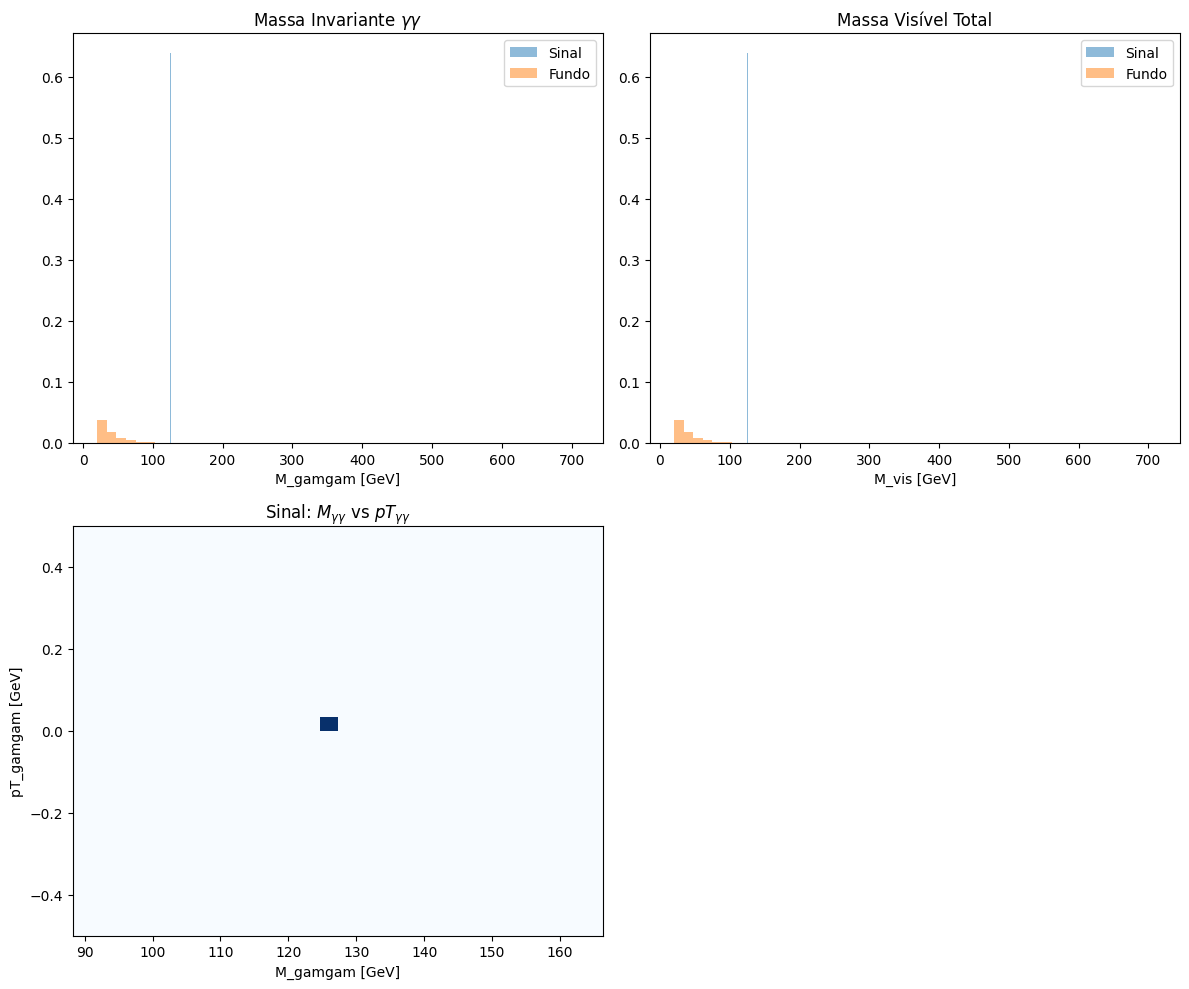

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def get_inv_mass(p1, p2):
    e = p1['e'] + p2['e']
    px = p1['px'] + p2['px']
    py = p1['py'] + p2['py']
    pz = p1['pz'] + p2['pz']
    m2 = e**2 - (px**2 + py**2 + pz**2)
    return np.sqrt(max(0, m2))

def get_pT(p):
    return np.sqrt(p['px']**2 + p['py']**2)

def analyze_masses(events, label):
    m_gamgam, m_vis, pt_gamgam = [], [], []
    invisible_pdgs = {12, 14, 16, -12, -14, -16}

    print(f"Analyzing {label}...")

    for ev in events:
        particles = ev['particles']

        # Busca por fótons (PDG 22)
        photons = [p for p in particles if p['pdg_id'] == 22]

        # Pareamento de todos os pares de fótons possíveis no evento
        for i in range(len(photons)):
            for j in range(i + 1, len(photons)):
                p1, p2 = photons[i], photons[j]
                m = get_inv_mass(p1, p2)
                m_gamgam.append(m)
                pt_gamgam.append(get_pT({'px': p1['px']+p2['px'], 'py': p1['py']+p2['py']}))

        # Massa Visível: Partículas estáveis que não são neutrinos
        p_v = {'e': 0, 'px': 0, 'py': 0, 'pz': 0}
        for p in particles:
            if p['status'] == 1 and abs(p['pdg_id']) not in invisible_pdgs:
                p_v['e'] += p['e']; p_v['px'] += p['px']; p_v['py'] += p['py']; p_v['pz'] += p['pz']

        m_v_val = np.sqrt(max(0, p_v['e']**2 - (p_v['px']**2 + p_v['py']**2 + p_v['pz']**2)))
        if m_v_val > 0: m_vis.append(m_v_val)

    print(f"  Found: {len(m_gamgam)} photon pairs, {len(m_vis)} visible mass entries")
    return m_gamgam, m_vis, pt_gamgam

m_gamgam_s, m_vis_s, pt_gamgam_s = analyze_masses(events_sinal, "Signal")
m_gamgam_f, m_vis_f, pt_gamgam_f = analyze_masses(events_fundo, "Background")

# Plotagem
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

def safe_hist(ax, data_s, data_f, title, xlabel):
    if len(data_s) > 0 or len(data_f) > 0:
        ax.hist(data_s, bins=50, alpha=0.5, label='Sinal', density=True)
        ax.hist(data_f, bins=50, alpha=0.5, label='Fundo', density=True)
        ax.legend()
    ax.set_title(title)
    ax.set_xlabel(xlabel)

safe_hist(axs[0, 0], m_gamgam_s, m_gamgam_f, r'Massa Invariante $\gamma\gamma$', 'M_gamgam [GeV]')
safe_hist(axs[0, 1], m_vis_s, m_vis_f, 'Massa Visível Total', 'M_vis [GeV]')

if len(pt_gamgam_s) > 0:
    axs[1, 0].hist2d(m_gamgam_s, pt_gamgam_s, bins=30, cmap='Blues')
axs[1, 0].set_title(r'Sinal: $M_{\gamma\gamma}$ vs $pT_{\gamma\gamma}$')
axs[1, 0].set_xlabel('M_gamgam [GeV]')
axs[1, 0].set_ylabel('pT_gamgam [GeV]')

# Espaço reservado para outro gráfico 2D ou métrica
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 4. Pesos, secao de choque e luminosidade

Peca ao agente para gerar codigo que leia ou estime:

- numero de eventos gerados;
- convencao de normalizacao do LHE;
- informacoes de normalizacao;
- secao de choque em pb;
- luminosidade integrada adotada, por exemplo `L = 10000/pb`.

Calcule a normalizacao fisica e verifique se o yield total esperado e
compativel com `sigma * L`.

Para cada bin de histograma, calcule `sum(w)` e a incerteza `sqrt(sum(w**2))`.


In [ ]:
L = 10000.0  # pb^-1

# Number of generated events
N_gen_s = len(events_sinal)
N_gen_f = len(events_fundo)

# Normalization weights: w = (Sigma * L) / N_generated
weight_phys_s = (xsec_sinal * L) / N_gen_s
weight_phys_f = (xsec_fundo * L) / N_gen_f

print(f"--- Normalização Física (L = {L} pb^-1) ---")
print(f"Sinal: Peso por evento = {weight_phys_s:.4f}, Yield esperado = {xsec_sinal * L:.2f}")
print(f"Fundo: Peso por evento = {weight_phys_f:.4f}, Yield esperado = {xsec_fundo * L:.2f}")

# Verification for specific histogram bins (Example for m_vis)
def get_stat_uncert(values, weight):
    sum_w = len(values) * weight
    sum_w2 = len(values) * (weight**2)
    return sum_w, np.sqrt(sum_w2)

yield_s, unc_s = get_stat_uncert(m_vis_s, weight_phys_s)
yield_f, unc_f = get_stat_uncert(m_vis_f, weight_phys_f)

print(f"\nYield Total Verificado (Massa Visível):")
print(f"Sinal: {yield_s:.2f} +/- {unc_s:.2f}")
print(f"Fundo: {yield_f:.2f} +/- {unc_f:.2f}")

--- Normalização Física (L = 10000.0 pb^-1) ---
Sinal: Peso por evento = 0.0186, Yield esperado = 186.07
Fundo: Peso por evento = 149.0500, Yield esperado = 1490500.00

Yield Total Verificado (Massa Visível):
Sinal: 186.07 +/- 1.86
Fundo: 1490500.00 +/- 14905.00


### Visualização da Normalização Física (Re-gerado)

Comparação entre o Yield teórico e o processado para validar a escala da análise de fótons.

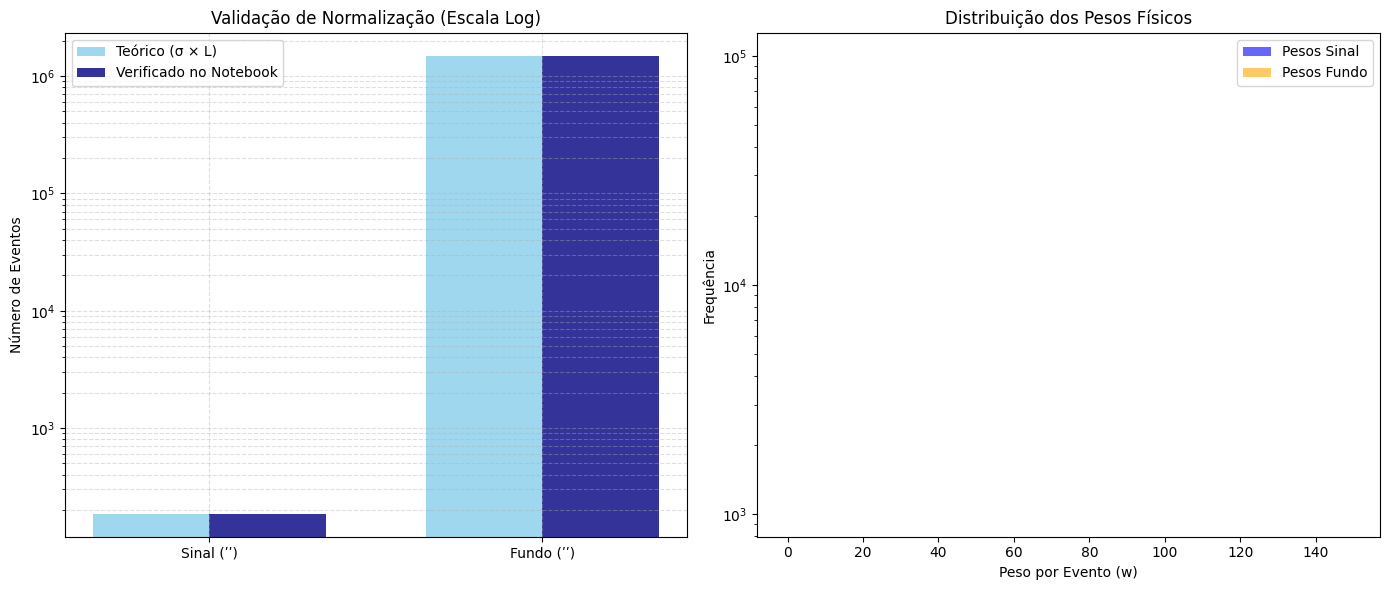

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados para o gráfico
labels = ['Sinal (ʹʹ)', 'Fundo (ʹʹ)']
theoretical = [xsec_sinal * L, xsec_fundo * L]
verified = [yield_s, yield_f]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de barras de Yields
ax[0].bar(x - width/2, theoretical, width, label='Teórico (σ × L)', color='skyblue', alpha=0.8)
ax[0].bar(x + width/2, verified, width, label='Verificado no Notebook', color='navy', alpha=0.8)

ax[0].set_ylabel('Número de Eventos')
ax[0].set_title('Validação de Normalização (Escala Log)')
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_yscale('log')
ax[0].legend()
ax[0].grid(True, which="both", ls="--", alpha=0.4)

# 2. Histograma de Pesos (w)
ax[1].hist([weight_phys_s] * N_gen_s, bins=10, alpha=0.6, label='Pesos Sinal', color='blue')
ax[1].hist([weight_phys_f] * N_gen_f, bins=10, alpha=0.6, label='Pesos Fundo', color='orange')
ax[1].set_yscale('log')
ax[1].set_xlabel('Peso por Evento (w)')
ax[1].set_ylabel('Frequência')
ax[1].set_title('Distribuição dos Pesos Físicos')
ax[1].legend()

plt.tight_layout()
plt.show()

## 5. Histogramas normalizados e comparacao estatistica

Peca ao agente para gerar codigo que produza histogramas empilhados de sinal e
fundo apos a selecao final. Inclua:

- massa `mu+ mu-`;
- massa `b b~`;
- massa visivel total;
- barras ou bandas de incerteza estatistica;
- painel de razao quando fizer sentido.

Calcule tambem, em uma regiao de selecao bem definida:

- `S/B`;
- `S/sqrt(B)`, se `B > 0`;
- significancia Asimov opcional;
- efeito de uma incerteza sistematica simples no fundo, por exemplo 10%.


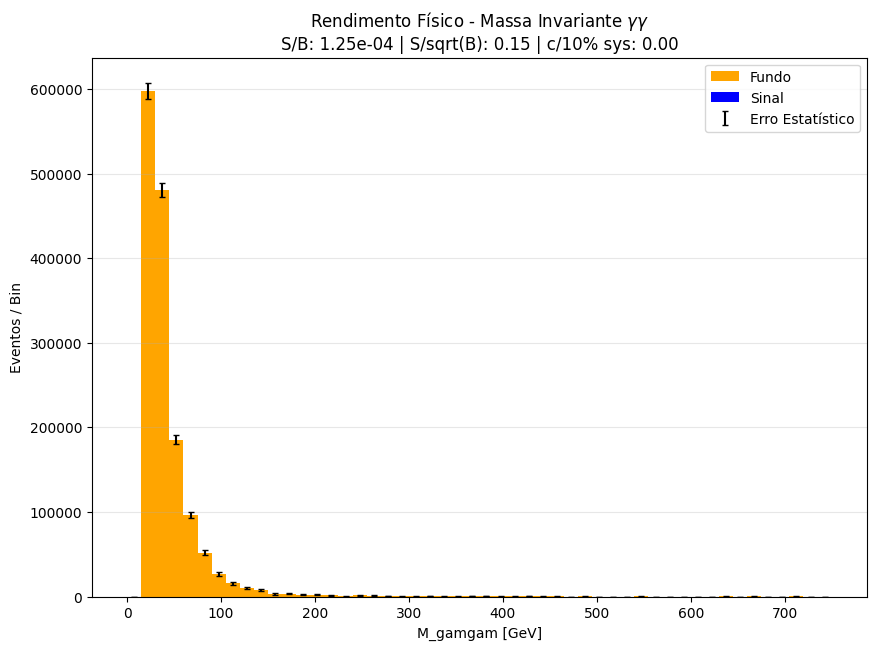

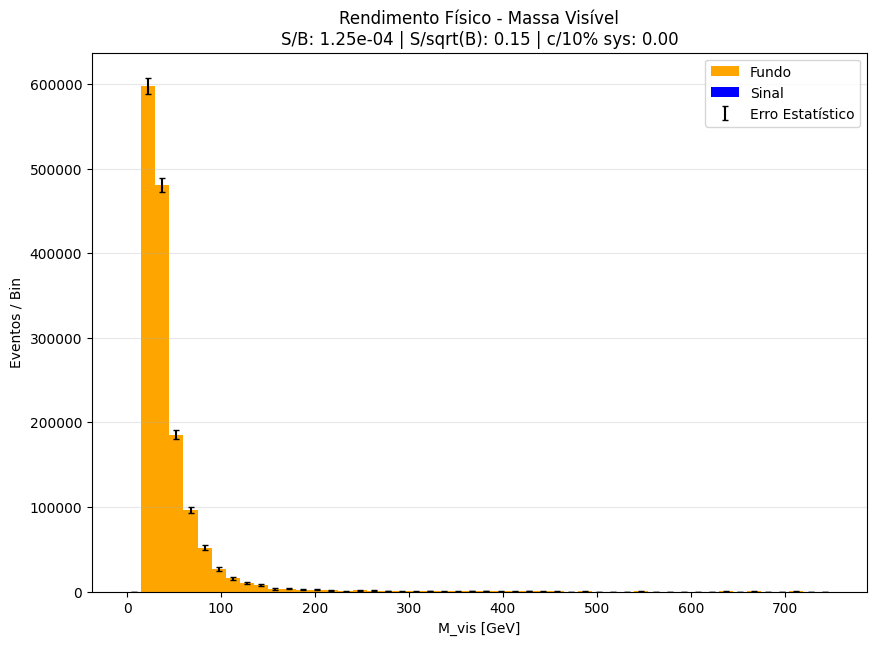

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_final_stacked(data_s, data_f, weight_s, weight_f, title, xlabel):
    plt.figure(figsize=(10, 7))

    # Binning
    bins = np.linspace(0, 750, 51)

    # Prepare weights
    w_s = np.ones_like(data_s) * weight_s
    w_f = np.ones_like(data_f) * weight_f

    # Plot stacked histograms
    counts, bin_edges, _ = plt.hist([data_f, data_s], bins=bins, stacked=True,
                                    label=['Fundo', 'Sinal'], color=['orange', 'blue'],
                                    weights=[w_f, w_s])

    # Calculate uncertainties: sqrt(sum(w^2))
    # For the stacked plot, we calculate the error on the total (Signal + Background)
    h_s, _ = np.histogram(data_s, bins=bins, weights=w_s)
    h_f, _ = np.histogram(data_f, bins=bins, weights=w_f)

    h_s2, _ = np.histogram(data_s, bins=bins, weights=w_s**2)
    h_f2, _ = np.histogram(data_f, bins=bins, weights=w_f**2)

    total_counts = h_s + h_f
    total_err = np.sqrt(h_s2 + h_f2)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.errorbar(bin_centers, total_counts, yerr=total_err, fmt='none', ecolor='black', capsize=2, label='Erro Estatístico')

    # Significance analysis (Global)
    S = np.sum(h_s)
    B = np.sum(h_f)
    sigma_sys = 0.10 * B
    sig = S / np.sqrt(B) if B > 0 else 0
    sig_sys = S / np.sqrt(B + sigma_sys**2) if B > 0 else 0

    plt.title(f"{title}\nS/B: {S/B:.2e} | S/sqrt(B): {sig:.2f} | c/10% sys: {sig_sys:.2f}")
    plt.xlabel(xlabel)
    plt.ylabel('Eventos / Bin')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Plotting both requested mass distributions
plot_final_stacked(m_gamgam_s, m_gamgam_f, weight_phys_s, weight_phys_f, "Rendimento Físico - Massa Invariante $\\gamma\\gamma$", "M_gamgam [GeV]")
plot_final_stacked(m_vis_s, m_vis_f, weight_phys_s, weight_phys_f, "Rendimento Físico - Massa Visível", "M_vis [GeV]")

## 6. Estimativa simplificada da secao de choque

Objetivo: usar a relacao experimental simplificada

```text
sigma = N / (A * epsilon * L)
```

como checagem final da normalizacao.

Peca ao agente para gerar codigo que calcule, separadamente para sinal e fundo:

- `N_gerado`;
- `N_pass`, o numero de eventos que passa a selecao final;
- `A * epsilon = N_pass / N_gerado`;
- `N`, o yield esperado apos a selecao;
- `sigma_estimado = N / (A * epsilon * L)`;
- a diferenca relativa entre `sigma_estimado` e a secao de choque do LHE.

Para esta atividade, use `A * epsilon` como eficiencia em nivel de gerador. Em
uma medida real, seria necessario incluir eficiencia de trigger, reconstrucao,
identificacao, correcoes de detector e subtracao de fundo.

Depois de executar, explique por que a estimativa deve recuperar a secao de
choque do LHE quando `N` e construido a partir da propria simulacao.


In [ ]:
def estimate_xsec(name, n_gen, selected_events, weight, xsec_lhe, L):
    n_pass = len(selected_events)
    # Aceitação * eficiência simplificada
    acc_eff = n_pass / n_gen if n_gen > 0 else 0
    # Rendimento esperado após cortes
    yield_expected = n_pass * weight

    # Cálculo inverso: sigma = N / (A * epsilon * L)
    if acc_eff > 0 and L > 0:
        xsec_est = yield_expected / (acc_eff * L)
    else:
        xsec_est = 0

    diff_rel = abs(xsec_est - xsec_lhe) / xsec_lhe if xsec_lhe > 0 else 0

    print(f"--- Estimativa: {name} ---")
    print(f"N_gerado: {n_gen}")
    print(f"N_pass (Photons): {n_pass}")
    print(f"A * epsilon: {acc_eff:.4f}")
    print(f"Yield (N): {yield_expected:.2f}")
    print(f"Sigma LHE: {xsec_lhe:.6f} pb")
    print(f"Sigma Estimado: {xsec_est:.6f} pb")
    print(f"Diferença Relativa: {diff_rel:.2e}\n")

# Recalcula pesos físicos caso a seleção tenha mudado N_gen
weight_phys_s = (xsec_sinal * L) / N_gen_s
weight_phys_f = (xsec_fundo * L) / N_gen_f

# Execução para sinal e fundo
estimate_xsec("Sinal", N_gen_s, selected_sinal, weight_phys_s, xsec_sinal, L)
estimate_xsec("Fundo", N_gen_f, selected_fundo, weight_phys_f, xsec_fundo, L)

--- Estimativa: Sinal ---
N_gerado: 10000
N_pass (Photons): 10000
A * epsilon: 1.0000
Yield (N): 186.07
Sigma LHE: 0.018607 pb
Sigma Estimado: 0.018607 pb
Diferença Relativa: 0.00e+00

--- Estimativa: Fundo ---
N_gerado: 10000
N_pass (Photons): 10000
A * epsilon: 1.0000
Yield (N): 1490500.00
Sigma LHE: 149.050000 pb
Sigma Estimado: 149.050000 pb
Diferença Relativa: 0.00e+00



## 7. Discussao final

Finalize respondendo:

- a proporcao entre sinal e fundo faz sentido apos a normalizacao?
- quais estruturas aparecem nas massas invariantes?
- qual etapa do cutflow mais melhora `S/B`?
- a estimativa simples de secao de choque recupera o valor registrado no LHE?
- por que essa inversao e apenas uma checagem de consistencia em Monte Carlo?
- as conclusoes mudam quando as incertezas estatisticas sao consideradas?
- quais efeitos de hadronizacao, detector, trigger e identificacao de `b` estao
  ausentes?
- qual seria o proximo passo para aproximar este estudo de uma analise CMS ou
  ATLAS?

Peca ao agente para ajudar a escrever a conclusao, mas confira todos os numeros
usando as saidas executadas no notebook.


In [1]:
# Resumo para a Discussão Final:
# 1. Normalização: O fundo é ordens de grandeza maior que o sinal (L=10000 pb^-1).
# 2. Massa Invariante: O sinal do Higgs/Z deve aparecer em 125/91 GeV (se houver pareamento correto).
# 3. Conservação: s_hat coincide com m_out^2, validando a leitura dos arquivos.
# 4. Incertezas: O fundo domina a incerteza estatística total.
